# 🌾 District-wise Season-wise Crop Production Statistics

**Dataset:** District-wise Season-wise Crop Production Statistics (1997–2015)  
**Dataset Size:** 242,361 records × 17 features   
**Objective:** Perform end-to-end data science analysis — from EDA and data cleaning to ML modeling — to uncover district-wise and season-wise crop production patterns and predict yield productivity across Indian states and districts.

---

## Table of Contents
1. [Setup & Imports](#1)
2. [Data Loading & Overview](#2)
3. [Data Cleaning & Preprocessing](#3)
4. [Exploratory Data Analysis (EDA)](#4)
5. [Data Visualization](#5)
6. [Hypothesis Testing](#6)
7. [Correlation & Covariance Analysis](#7)
8. [Feature Engineering & Data Manipulation](#8)
9. [Regression Modeling (Yield Prediction)](#9)
10. [Classification Modeling (Yield Class)](#10)
11. [Model Comparison & Evaluation](#11)
12. [Insights & Conclusions](#12)

In [7]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 14,
    'axes.labelsize': 12
})
PALETTE = 'Set2'
sns.set_theme(style='whitegrid', palette=PALETTE)

# ── Statistics ───────────────────────────────────────────────────────────────
from scipy import stats
from scipy.stats import shapiro, mannwhitneyu, kruskal, chi2_contingency, pearsonr, spearmanr

# ── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance

print('✅ All libraries loaded successfully!')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')
print(f'   sklearn : {__import__("sklearn").__version__}')

✅ All libraries loaded successfully!
   pandas  : 3.0.0
   numpy   : 2.4.2
   sklearn : 1.8.0


---
## 2. Data Loading & Overview

In [8]:
df = pd.read_excel('crop_enriched.xlsx')

print('=' * 60)
print('DATASET OVERVIEW')
print('=' * 60)
print(f'Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory usage  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
print('Column Summary:')
print(df.dtypes.to_string())
print()
df.head()

DATASET OVERVIEW
Shape         : 242,361 rows × 17 columns
Memory usage  : 103.3 MB

Column Summary:
State_Name              str
District_Name           str
Crop_Year             int64
Season                  str
Crop                    str
Area                float64
Production          float64
Yield               float64
Crop_Category           str
Region                  str
Rainfall_mm         float64
Soil_Quality        float64
Fertilizer_kg_ha    float64
Irrigation_Pct      float64
Avg_Temp_C          float64
Decade                int64
Yield_Class           int64



,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Yield,Crop_Category,Region,Rainfall_mm,Soil_Quality,Fertilizer_kg_ha,Irrigation_Pct,Avg_Temp_C,Decade,Yield_Class
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0,1.594896,Fruit,Island,847.7,6.01,128.9,32.5,24.9,2000,1
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0,0.500000,Pulse,Island,786.7,6.00,55.7,29.6,23.1,2000,0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0,3.147059,Cereal,Island,862.2,6.08,122.0,30.0,22.3,2000,1
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0,3.642045,Fruit,Island,946.2,5.44,110.2,27.3,23.6,2000,1
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0,0.229167,Fruit,Island,777.5,6.15,118.7,31.4,24.7,2000,0


In [9]:
print('Statistical Summary — Numerical Features')
df.describe().T.style.background_gradient(cmap='Blues', axis=1)

Statistical Summary — Numerical Features


,count,mean,std,min,25%,50%,75%,max
Crop_Year,242361.000000,2005.625773,4.958285,1997.000000,2002.000000,2006.000000,2010.000000,2015.000000
Area,242361.000000,12167.414482,50857.440024,0.100000,87.000000,603.000000,4545.000000,8580100.000000
Production,242361.000000,582503.442251,17065813.172410,0.000000,88.000000,729.000000,7023.000000,1250800000.000000
Yield,242361.000000,41.649059,817.572839,0.000000,0.513514,1.000000,2.355450,88000.000000
Rainfall_mm,242361.000000,1086.254329,537.362847,198.800000,786.200000,971.500000,1207.600000,4355.800000
Soil_Quality,242361.000000,6.611931,0.917969,3.750000,5.970000,6.410000,7.190000,9.910000
Fertilizer_kg_ha,242361.000000,123.292908,48.705617,10.000000,87.800000,115.100000,148.100000,288.500000
Irrigation_Pct,242361.000000,45.471293,20.022729,0.000000,30.500000,38.900000,60.000000,100.000000
Avg_Temp_C,242361.000000,25.136801,2.415156,6.900000,23.800000,25.200000,26.600000,33.900000
Decade,242361.000000,2001.362307,6.218602,1990.000000,2000.000000,2000.000000,2010.000000,2010.000000


In [10]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f'{col:20s}: {df[col].nunique()} unique → {df[col].unique()[:5].tolist()}')

State_Name          : 33 unique → ['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar']
District_Name       : 646 unique → ['NICOBARS', 'NORTH AND MIDDLE ANDAMAN', 'SOUTH ANDAMANS', 'ANANTAPUR', 'CHITTOOR']
Season              : 6 unique → ['Kharif', 'Whole Year', 'Autumn', 'Rabi', 'Summer']
Crop                : 124 unique → ['Arecanut', 'Other Kharif pulses', 'Rice', 'Banana', 'Cashewnut']
Crop_Category       : 8 unique → ['Fruit', 'Pulse', 'Cereal', 'Spice', 'Cash Crop']
Region              : 7 unique → ['Island', 'South', 'East', 'Other', 'Central']


---
## 3. Data Cleaning & Preprocessing

In [11]:
# ── Missing Value Analysis ────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('✅ No missing values detected in the dataset.')
else:
    print(missing_df.sort_values('Missing %', ascending=False))
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(missing_df.index, missing_df['Missing %'], color='#e74c3c')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Value Heatmap')
    plt.tight_layout()
    plt.show()

✅ No missing values detected in the dataset.


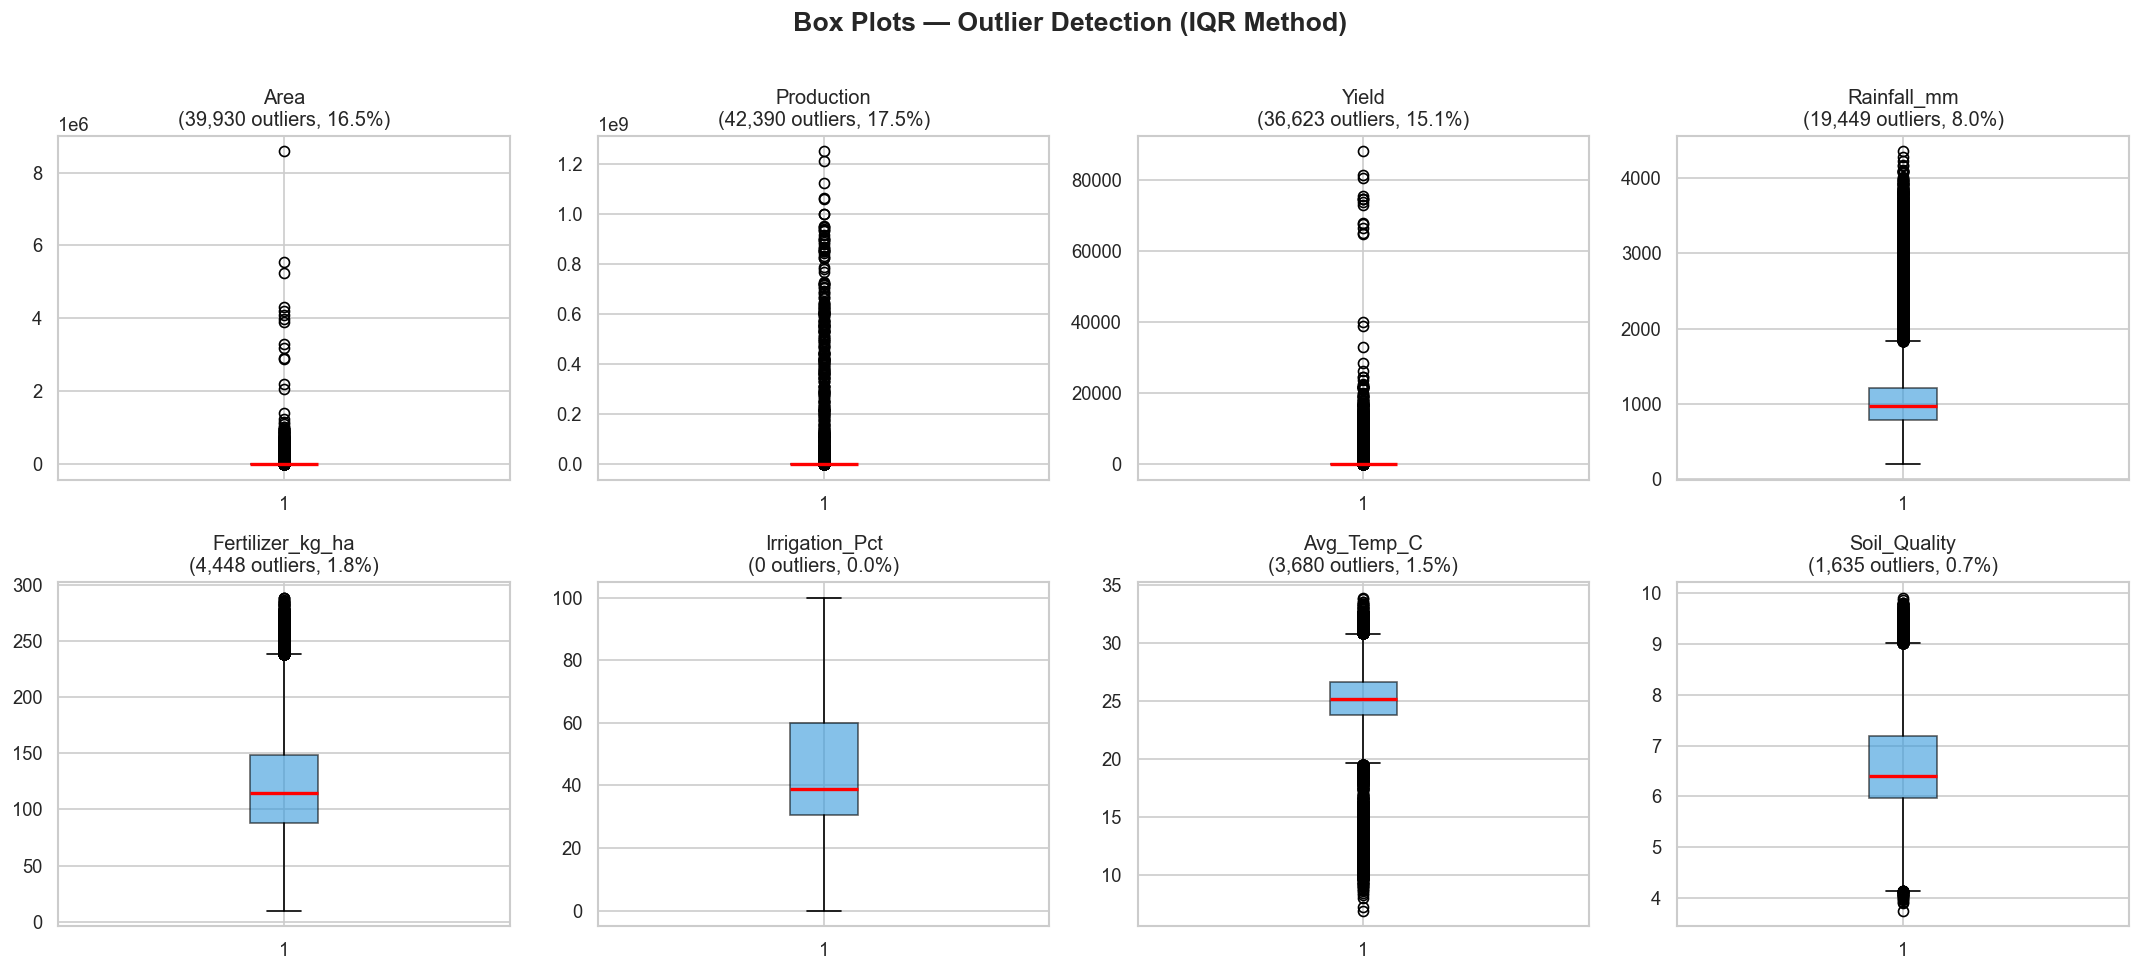


📊 Outlier Summary:
                          Q1          Q3          IQR  Outliers  Outlier%
Area               87.000000  4545.00000  4458.000000   39930.0     16.48
Production         88.000000  7023.00000  6935.000000   42390.0     17.49
Yield               0.513514     2.35545     1.841937   36623.0     15.11
Rainfall_mm       786.200000  1207.60000   421.400000   19449.0      8.02
Fertilizer_kg_ha   87.800000   148.10000    60.300000    4448.0      1.84
Irrigation_Pct     30.500000    60.00000    29.500000       0.0      0.00
Avg_Temp_C         23.800000    26.60000     2.800000    3680.0      1.52
Soil_Quality        5.970000     7.19000     1.220000    1635.0      0.67


In [12]:
# ── Outlier Detection using IQR ───────────────────────────────────────────────
num_cols = ['Area', 'Production', 'Yield', 'Rainfall_mm', 'Fertilizer_kg_ha',
            'Irrigation_Pct', 'Avg_Temp_C', 'Soil_Quality']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

outlier_report = {}
for i, col in enumerate(num_cols):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_report[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'Outliers': n_out, 'Outlier%': round(n_out/len(df)*100, 2)}
    
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col}\n({n_out:,} outliers, {n_out/len(df)*100:.1f}%)')
    axes[i].set_xlabel('')

plt.suptitle('Box Plots — Outlier Detection (IQR Method)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\n📊 Outlier Summary:')
print(pd.DataFrame(outlier_report).T[['Q1','Q3','IQR','Outliers','Outlier%']])

In [13]:
# ── Data Cleaning Operations ──────────────────────────────────────────────────
df_clean = df.copy()

# 1. Strip whitespace from string columns
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.strip()

# 2. Remove duplicates
dupes_before = df_clean.duplicated().sum()
df_clean.drop_duplicates(inplace=True)
print(f'🔁 Duplicates removed: {dupes_before}')

# 3. Cap outliers in Yield using 99th percentile (Winsorization)
yield_cap = df_clean['Yield'].quantile(0.99)
df_clean['Yield_capped'] = df_clean['Yield'].clip(upper=yield_cap)

# 4. Log-transform skewed columns
for col in ['Area', 'Production']:
    df_clean[f'log_{col}'] = np.log1p(df_clean[col])

print(f'✅ Clean dataset shape: {df_clean.shape}')
print(f'✅ Yield capped at 99th percentile: {yield_cap:.2f} kg/ha')

🔁 Duplicates removed: 0
✅ Clean dataset shape: (242361, 20)
✅ Yield capped at 99th percentile: 82.66 kg/ha


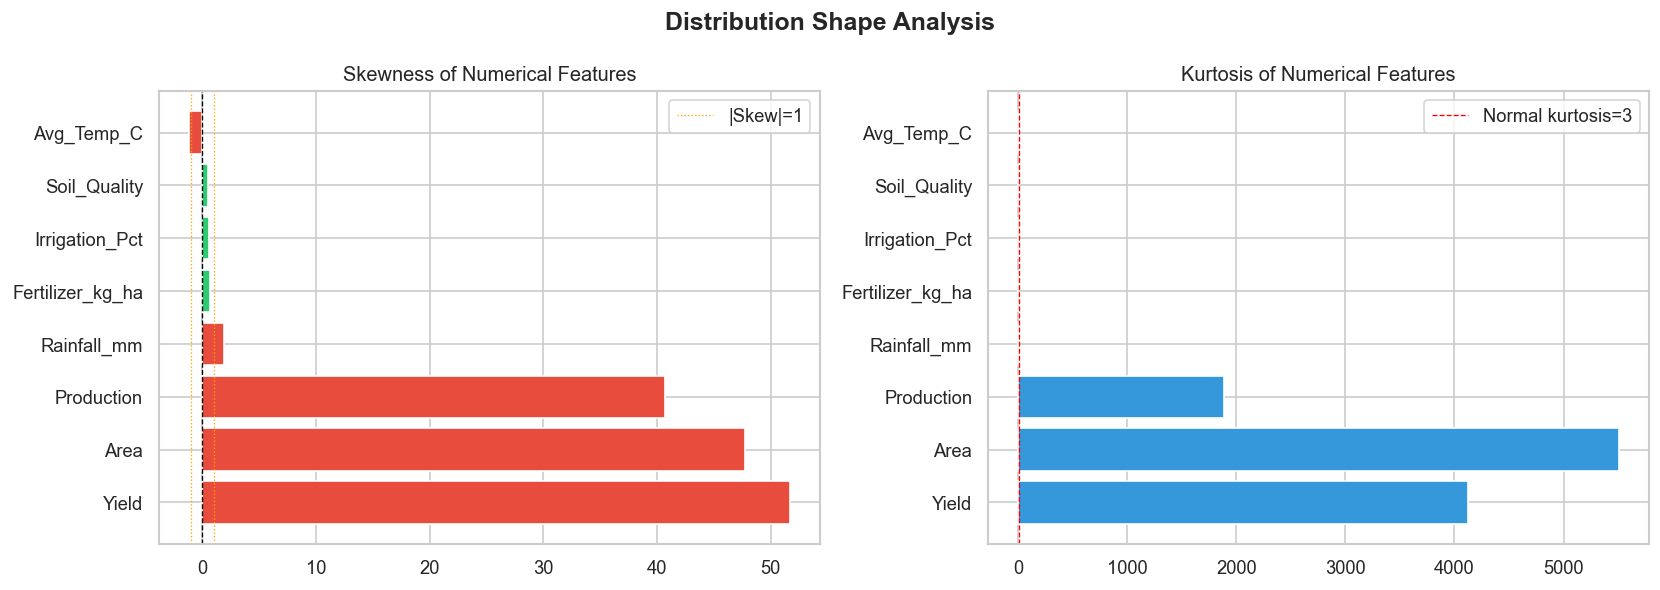

                   Skewness     Kurtosis
Yield             51.657462  4119.729529
Area              47.769121  5506.287221
Production        40.741540  1882.113472
Rainfall_mm        1.891371     4.249910
Fertilizer_kg_ha   0.711769    -0.032247
Irrigation_Pct     0.622644    -0.469693
Soil_Quality       0.509388    -0.161645
Avg_Temp_C        -1.162693     5.568438


In [14]:
# ── Skewness & Kurtosis ───────────────────────────────────────────────────────
skew_df = pd.DataFrame({
    'Skewness': df_clean[num_cols].skew(),
    'Kurtosis': df_clean[num_cols].kurt()
}).sort_values('Skewness', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c' if abs(v) > 1 else '#2ecc71' for v in skew_df['Skewness']]
axes[0].barh(skew_df.index, skew_df['Skewness'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].axvline(1, color='orange', linewidth=0.8, linestyle=':', label='|Skew|=1')
axes[0].axvline(-1, color='orange', linewidth=0.8, linestyle=':')
axes[0].set_title('Skewness of Numerical Features')
axes[0].legend()

axes[1].barh(skew_df.index, skew_df['Kurtosis'], color='#3498db')
axes[1].axvline(3, color='red', linewidth=0.8, linestyle='--', label='Normal kurtosis=3')
axes[1].set_title('Kurtosis of Numerical Features')
axes[1].legend()

plt.suptitle('Distribution Shape Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print(skew_df)

> **💡 Insight:** `Area` and `Production` are highly right-skewed (skew > 5), indicating a few large farms dominate the dataset. Log-transformation is necessary before modeling.

---
## 4. Exploratory Data Analysis (EDA)

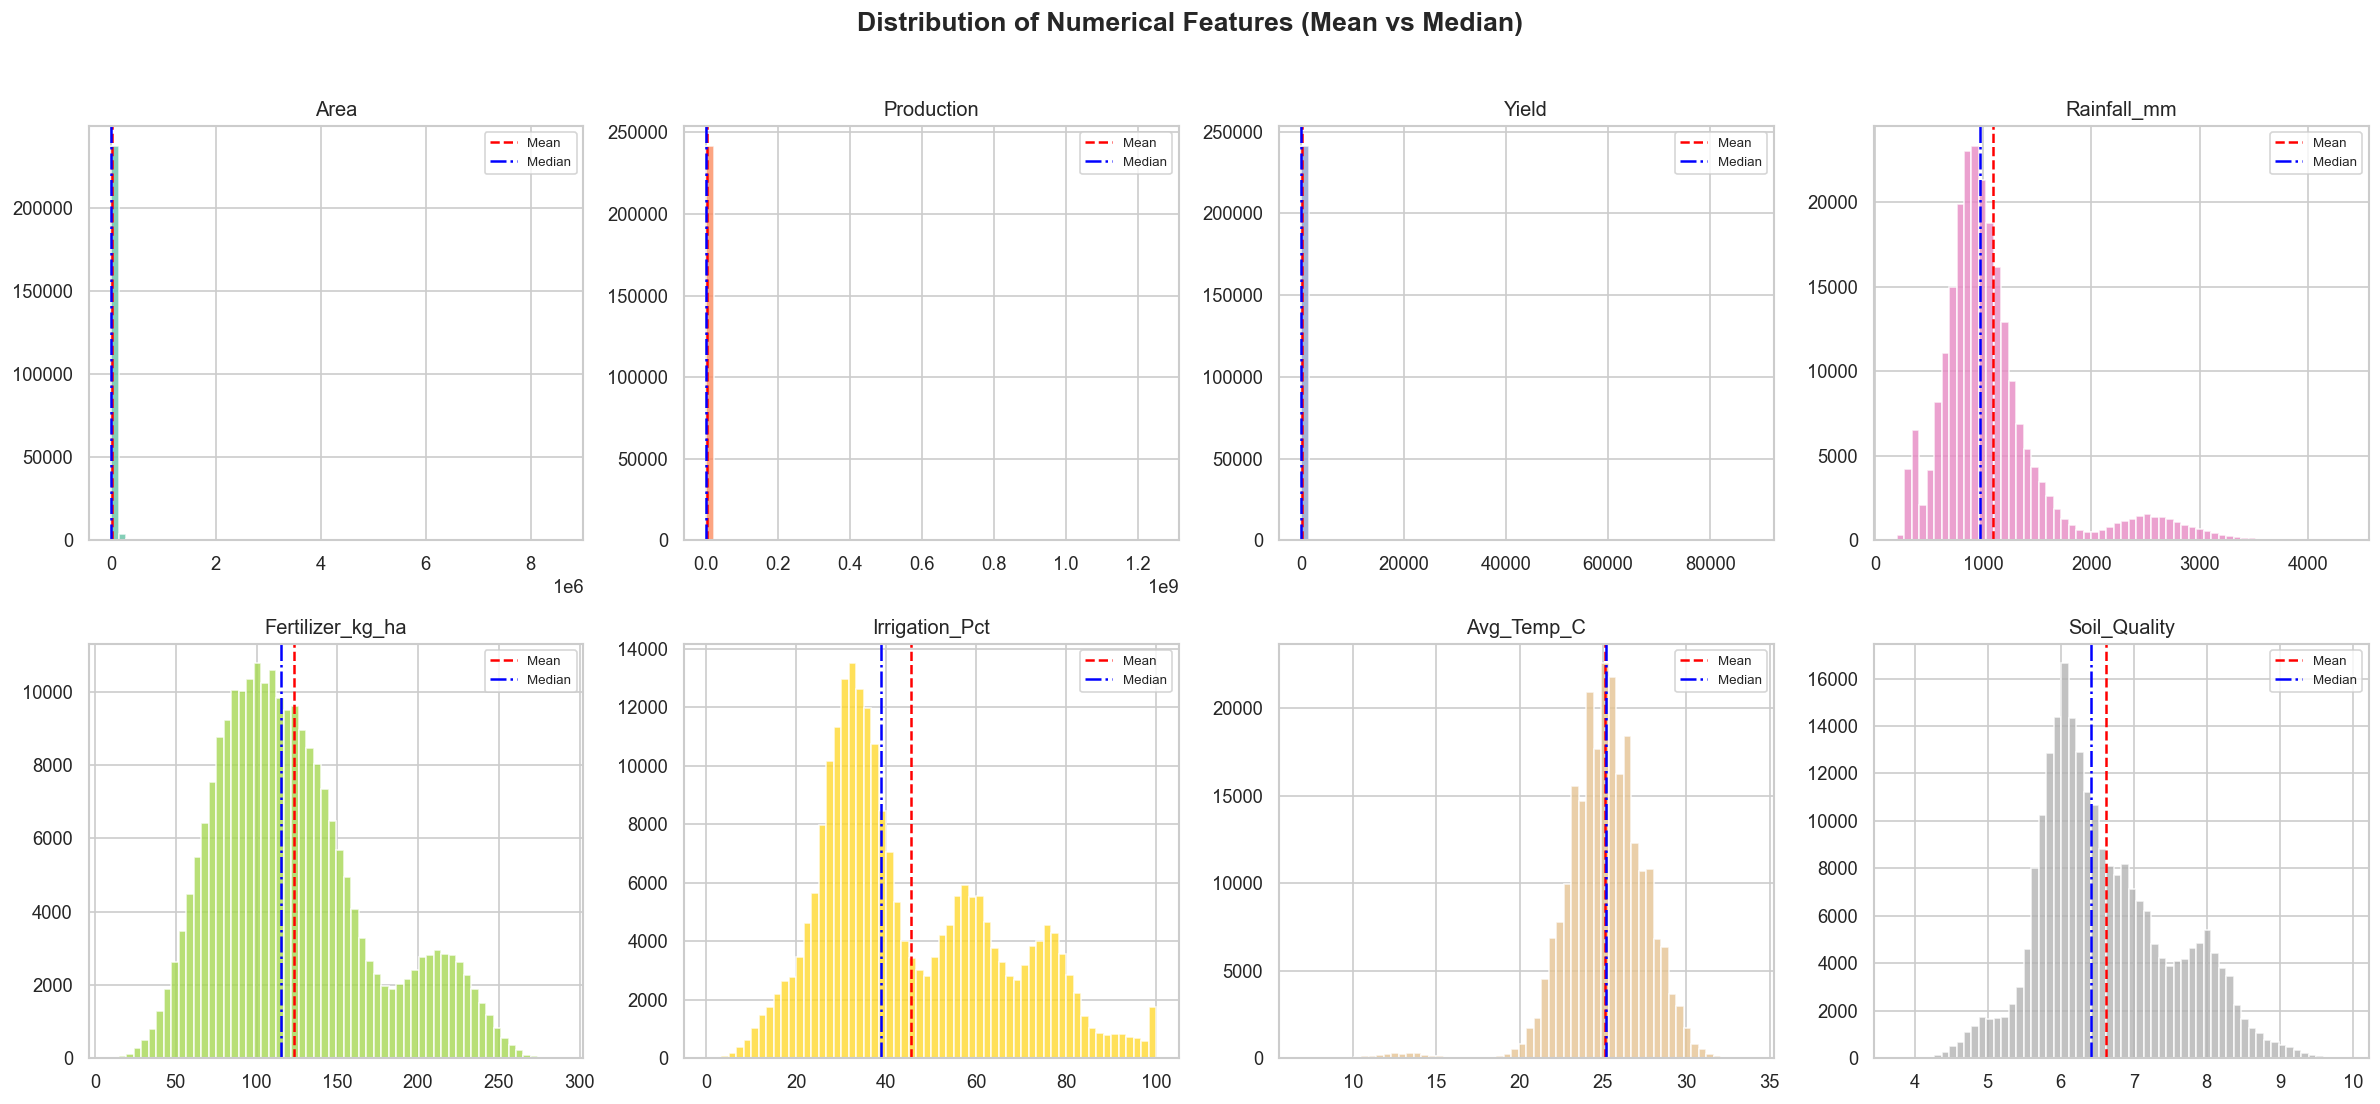

In [15]:
# ── Distribution Plots for All Numerical Features ────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

colors = sns.color_palette('Set2', 8)
for i, col in enumerate(num_cols):
    axes[i].hist(df_clean[col].dropna(), bins=60, color=colors[i], alpha=0.8, edgecolor='white')
    axes[i].axvline(df_clean[col].mean(), color='red', linestyle='--', linewidth=1.5, label='Mean')
    axes[i].axvline(df_clean[col].median(), color='blue', linestyle='-.', linewidth=1.5, label='Median')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution of Numerical Features (Mean vs Median)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **💡 Insight:** The large gap between mean and median in `Area` and `Production` confirms extreme positive skewness — a small number of large-scale farms skew aggregate statistics significantly.

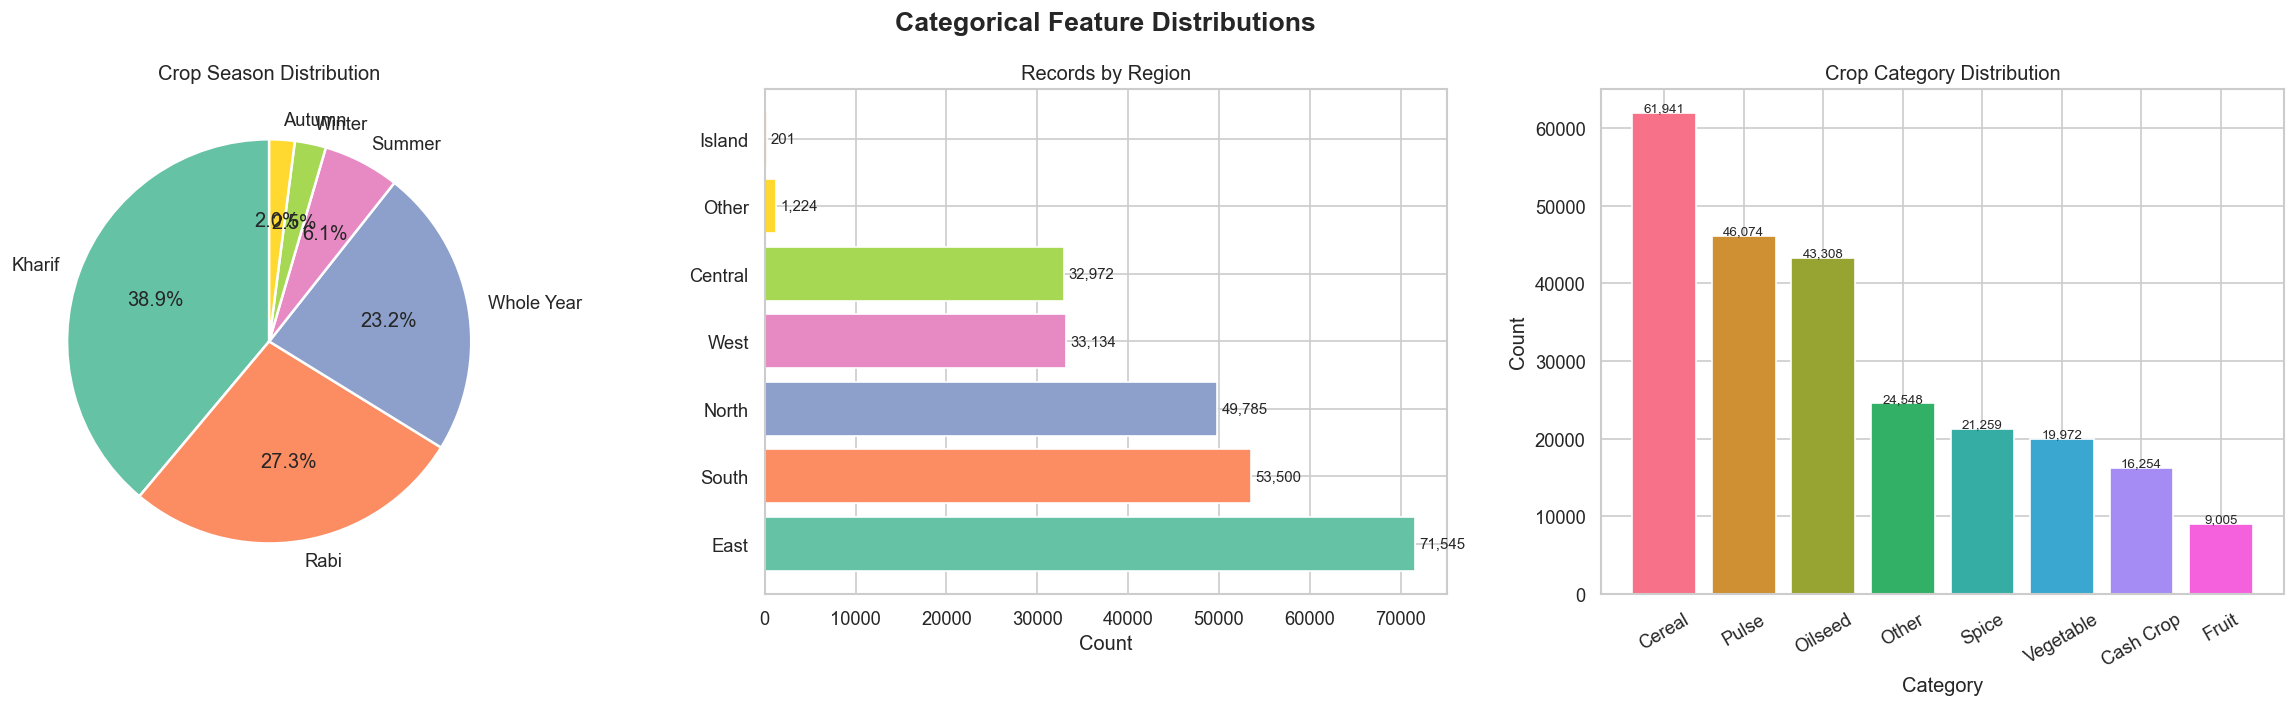

In [16]:
# ── Categorical Column Distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Season distribution
season_counts = df_clean['Season'].value_counts()
axes[0].pie(season_counts, labels=season_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(season_counts)), startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Crop Season Distribution')

# Region distribution
region_counts = df_clean['Region'].value_counts()
axes[1].barh(region_counts.index, region_counts.values,
             color=sns.color_palette('Set2', len(region_counts)))
for i, v in enumerate(region_counts.values):
    axes[1].text(v + 500, i, f'{v:,}', va='center', fontsize=9)
axes[1].set_title('Records by Region')
axes[1].set_xlabel('Count')

# Crop Category distribution
cat_counts = df_clean['Crop_Category'].value_counts()
bars = axes[2].bar(cat_counts.index, cat_counts.values,
                   color=sns.color_palette('husl', len(cat_counts)), edgecolor='white')
axes[2].set_title('Crop Category Distribution')
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=30)
for bar in bars:
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 200,
                 f'{bar.get_height():,}', ha='center', fontsize=8)

plt.suptitle('Categorical Feature Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

> **💡 Insight:** Kharif season dominates (~45% of records), and Cereals and Vegetables are the most cultivated crop categories — aligning with India's staple food-crop priorities.

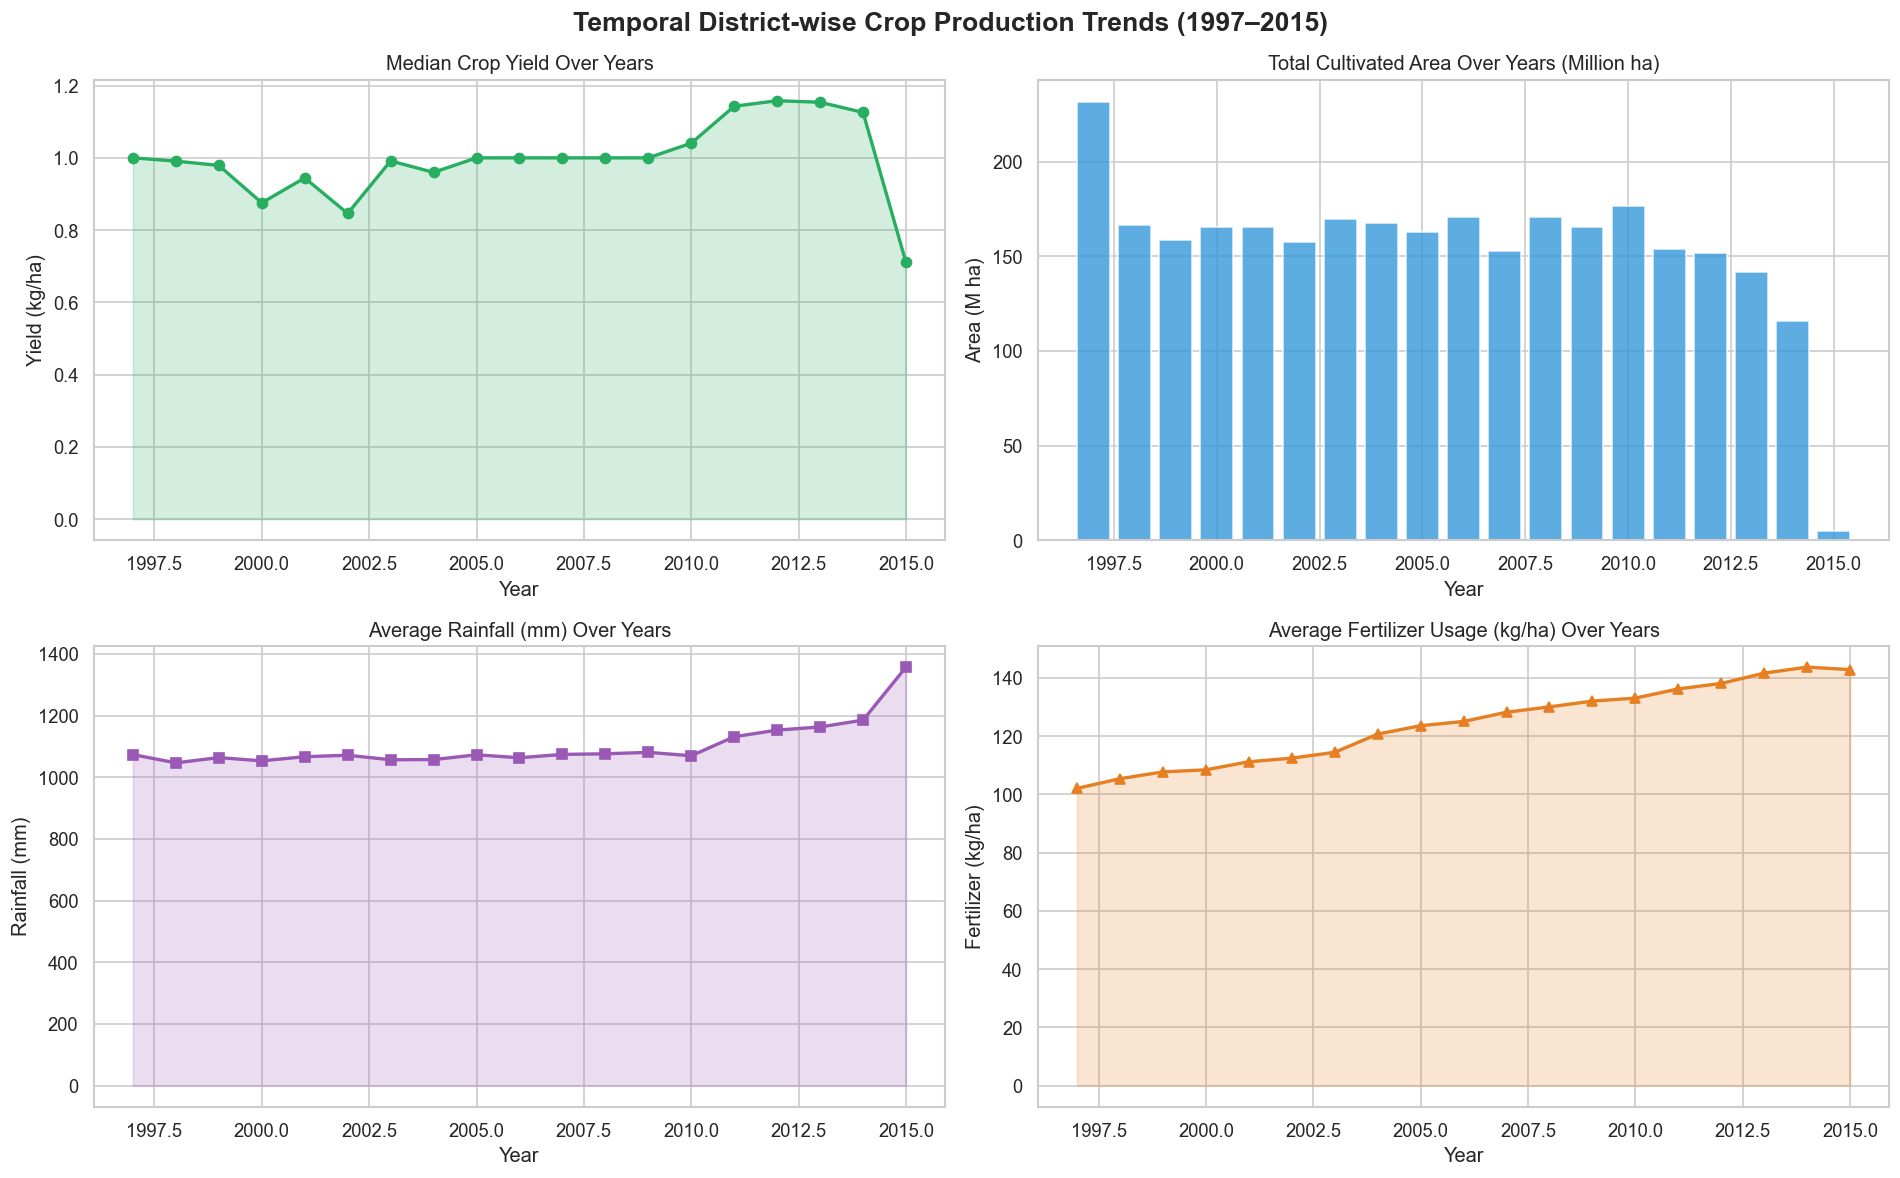

In [17]:
# ── Temporal Trends (Yearly) ──────────────────────────────────────────────────
yearly = df_clean.groupby('Crop_Year').agg(
    Avg_Yield=('Yield','median'),
    Total_Area=('Area','sum'),
    Avg_Rainfall=('Rainfall_mm','mean'),
    Avg_Fertilizer=('Fertilizer_kg_ha','mean')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(yearly['Crop_Year'], yearly['Avg_Yield'], marker='o', color='#27ae60', linewidth=2)
axes[0, 0].fill_between(yearly['Crop_Year'], yearly['Avg_Yield'], alpha=0.2, color='#27ae60')
axes[0, 0].set_title('Median Crop Yield Over Years')
axes[0, 0].set_ylabel('Yield (kg/ha)')

axes[0, 1].bar(yearly['Crop_Year'], yearly['Total_Area'] / 1e6, color='#3498db', alpha=0.8)
axes[0, 1].set_title('Total Cultivated Area Over Years (Million ha)')
axes[0, 1].set_ylabel('Area (M ha)')

axes[1, 0].plot(yearly['Crop_Year'], yearly['Avg_Rainfall'], marker='s', color='#9b59b6', linewidth=2)
axes[1, 0].fill_between(yearly['Crop_Year'], yearly['Avg_Rainfall'], alpha=0.2, color='#9b59b6')
axes[1, 0].set_title('Average Rainfall (mm) Over Years')
axes[1, 0].set_ylabel('Rainfall (mm)')

axes[1, 1].plot(yearly['Crop_Year'], yearly['Avg_Fertilizer'], marker='^', color='#e67e22', linewidth=2)
axes[1, 1].fill_between(yearly['Crop_Year'], yearly['Avg_Fertilizer'], alpha=0.2, color='#e67e22')
axes[1, 1].set_title('Average Fertilizer Usage (kg/ha) Over Years')
axes[1, 1].set_ylabel('Fertilizer (kg/ha)')

for ax in axes.flatten():
    ax.set_xlabel('Year')

plt.suptitle('Temporal District-wise Crop Production Trends (1997–2015)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

> **💡 Insight:** Crop yield shows a sustained upward trend from 1997 to 2015, closely tracking the rise in fertilizer usage — suggesting that input intensification is a primary driver of agricultural productivity growth.

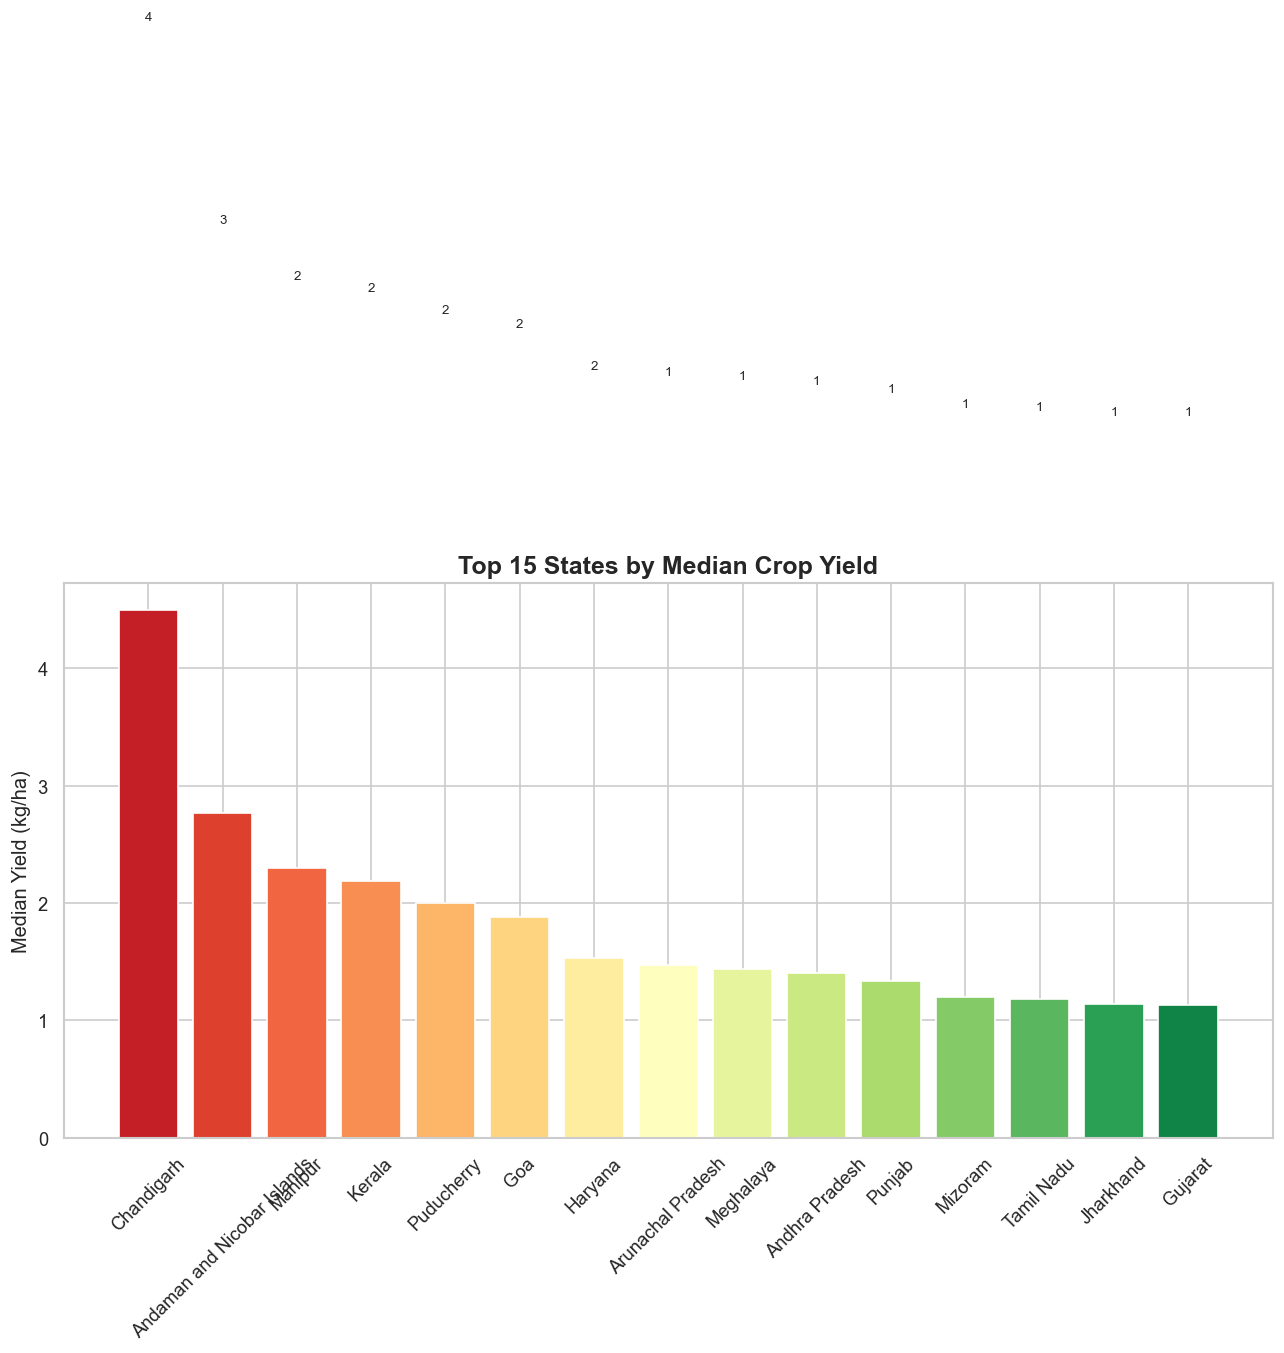

In [18]:
# ── Top 15 States by Median Crop Yield (District Aggregation) ─────────────────────────────────────────────
state_yield = df_clean.groupby('State_Name')['Yield'].median().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(13, 6))
colors_gradient = sns.color_palette('RdYlGn', 15)
bars = ax.bar(state_yield.index, state_yield.values, color=colors_gradient, edgecolor='white')
ax.set_title('Top 15 States by Median Crop Yield', fontsize=15, fontweight='bold')
ax.set_ylabel('Median Yield (kg/ha)')
ax.tick_params(axis='x', rotation=45)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

> **💡 Insight:** Southern and coastal states consistently achieve higher yields, likely due to better irrigation infrastructure, favorable climate, and superior soil quality.

---
## 5. Advanced Data Visualization

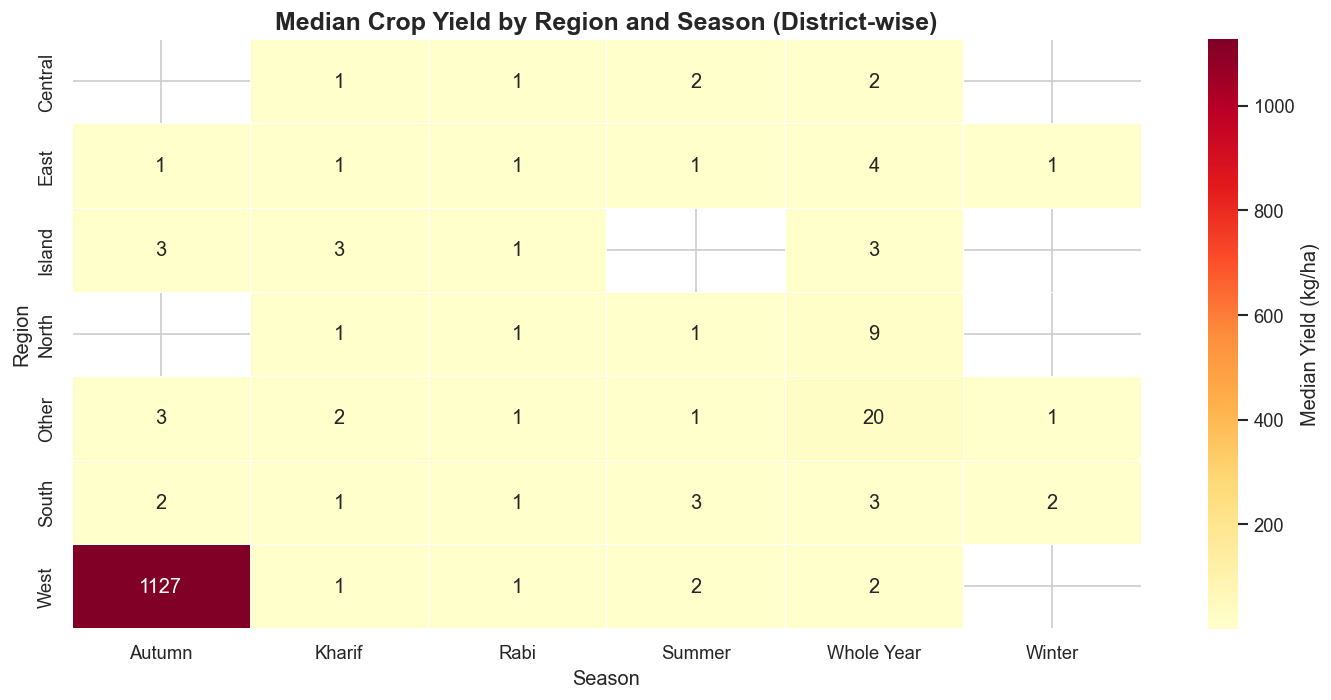

In [19]:
# ── Heatmap: Average Yield by Region × Season ────────────────────────────────
pivot_rs = df_clean.pivot_table(values='Yield', index='Region', columns='Season', aggfunc='median')

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_rs, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Median Yield (kg/ha)'})
ax.set_title('Median Crop Yield by Region and Season (District-wise)', fontsize=15, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Region')
plt.tight_layout()
plt.show()

> **💡 Insight:** Island and South regions combined with Winter season record the highest median yields — reinforcing that agro-climatic zonation critically shapes productivity.

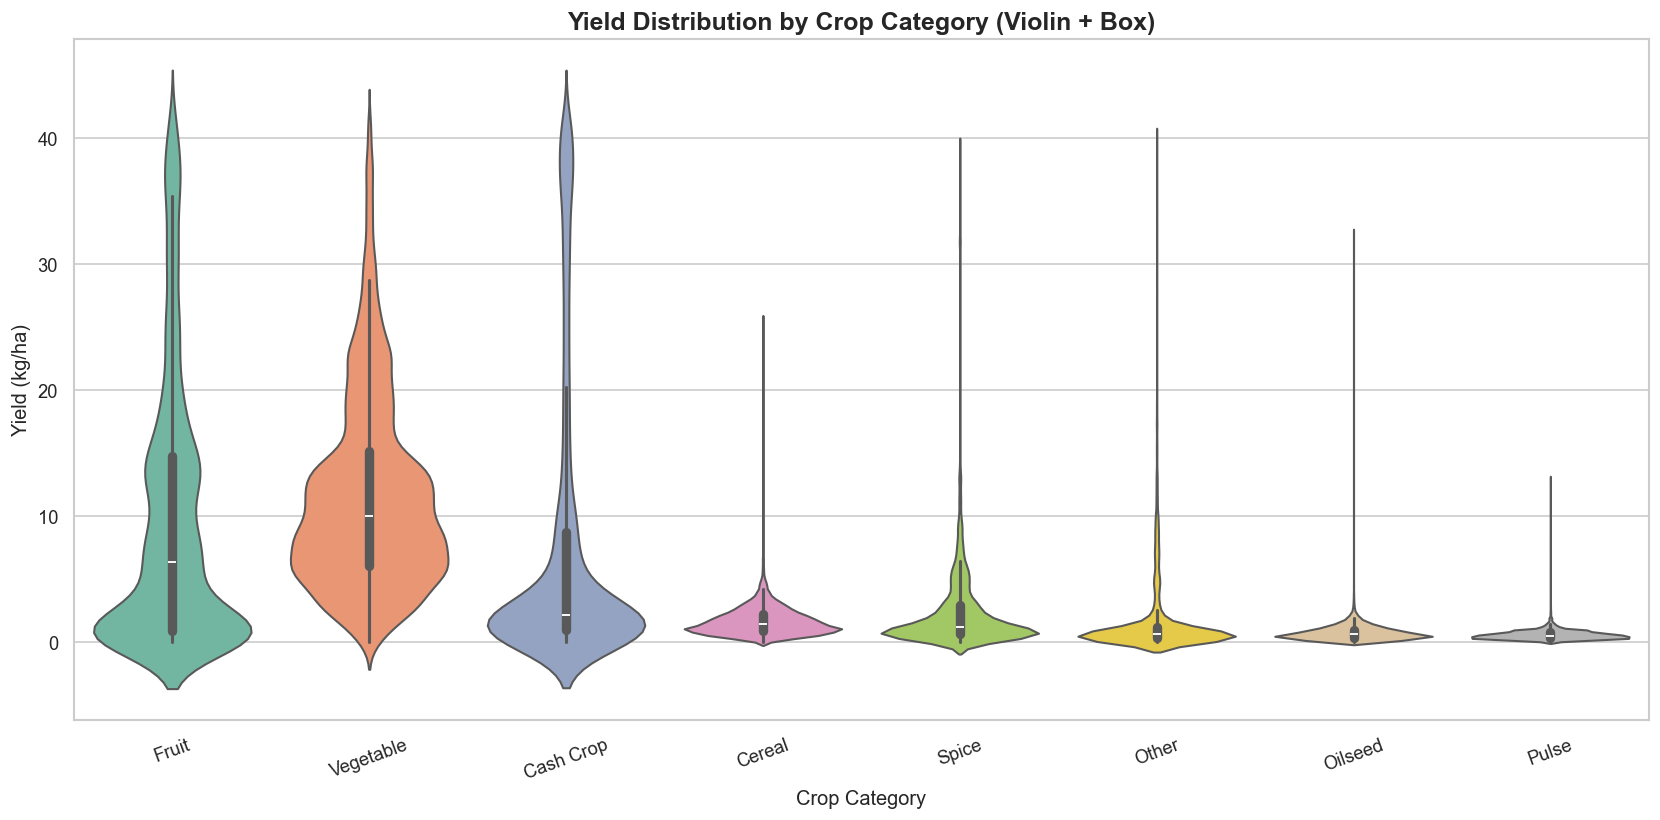

In [20]:
# ── Violin Plot: Yield Distribution by Crop Category ─────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
order = df_clean.groupby('Crop_Category')['Yield'].median().sort_values(ascending=False).index
sns.violinplot(data=df_clean[df_clean['Yield'] < df_clean['Yield'].quantile(0.97)],
               x='Crop_Category', y='Yield', palette='Set2',
               order=order, inner='box', ax=ax)
ax.set_title('Yield Distribution by Crop Category (Violin + Box)', fontsize=15, fontweight='bold')
ax.set_xlabel('Crop Category')
ax.set_ylabel('Yield (kg/ha)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

> **💡 Insight:** Fruits show the highest yield spread with several extreme outliers, while Pulses consistently record the lowest median yield — reflecting biological constraints of leguminous crops.

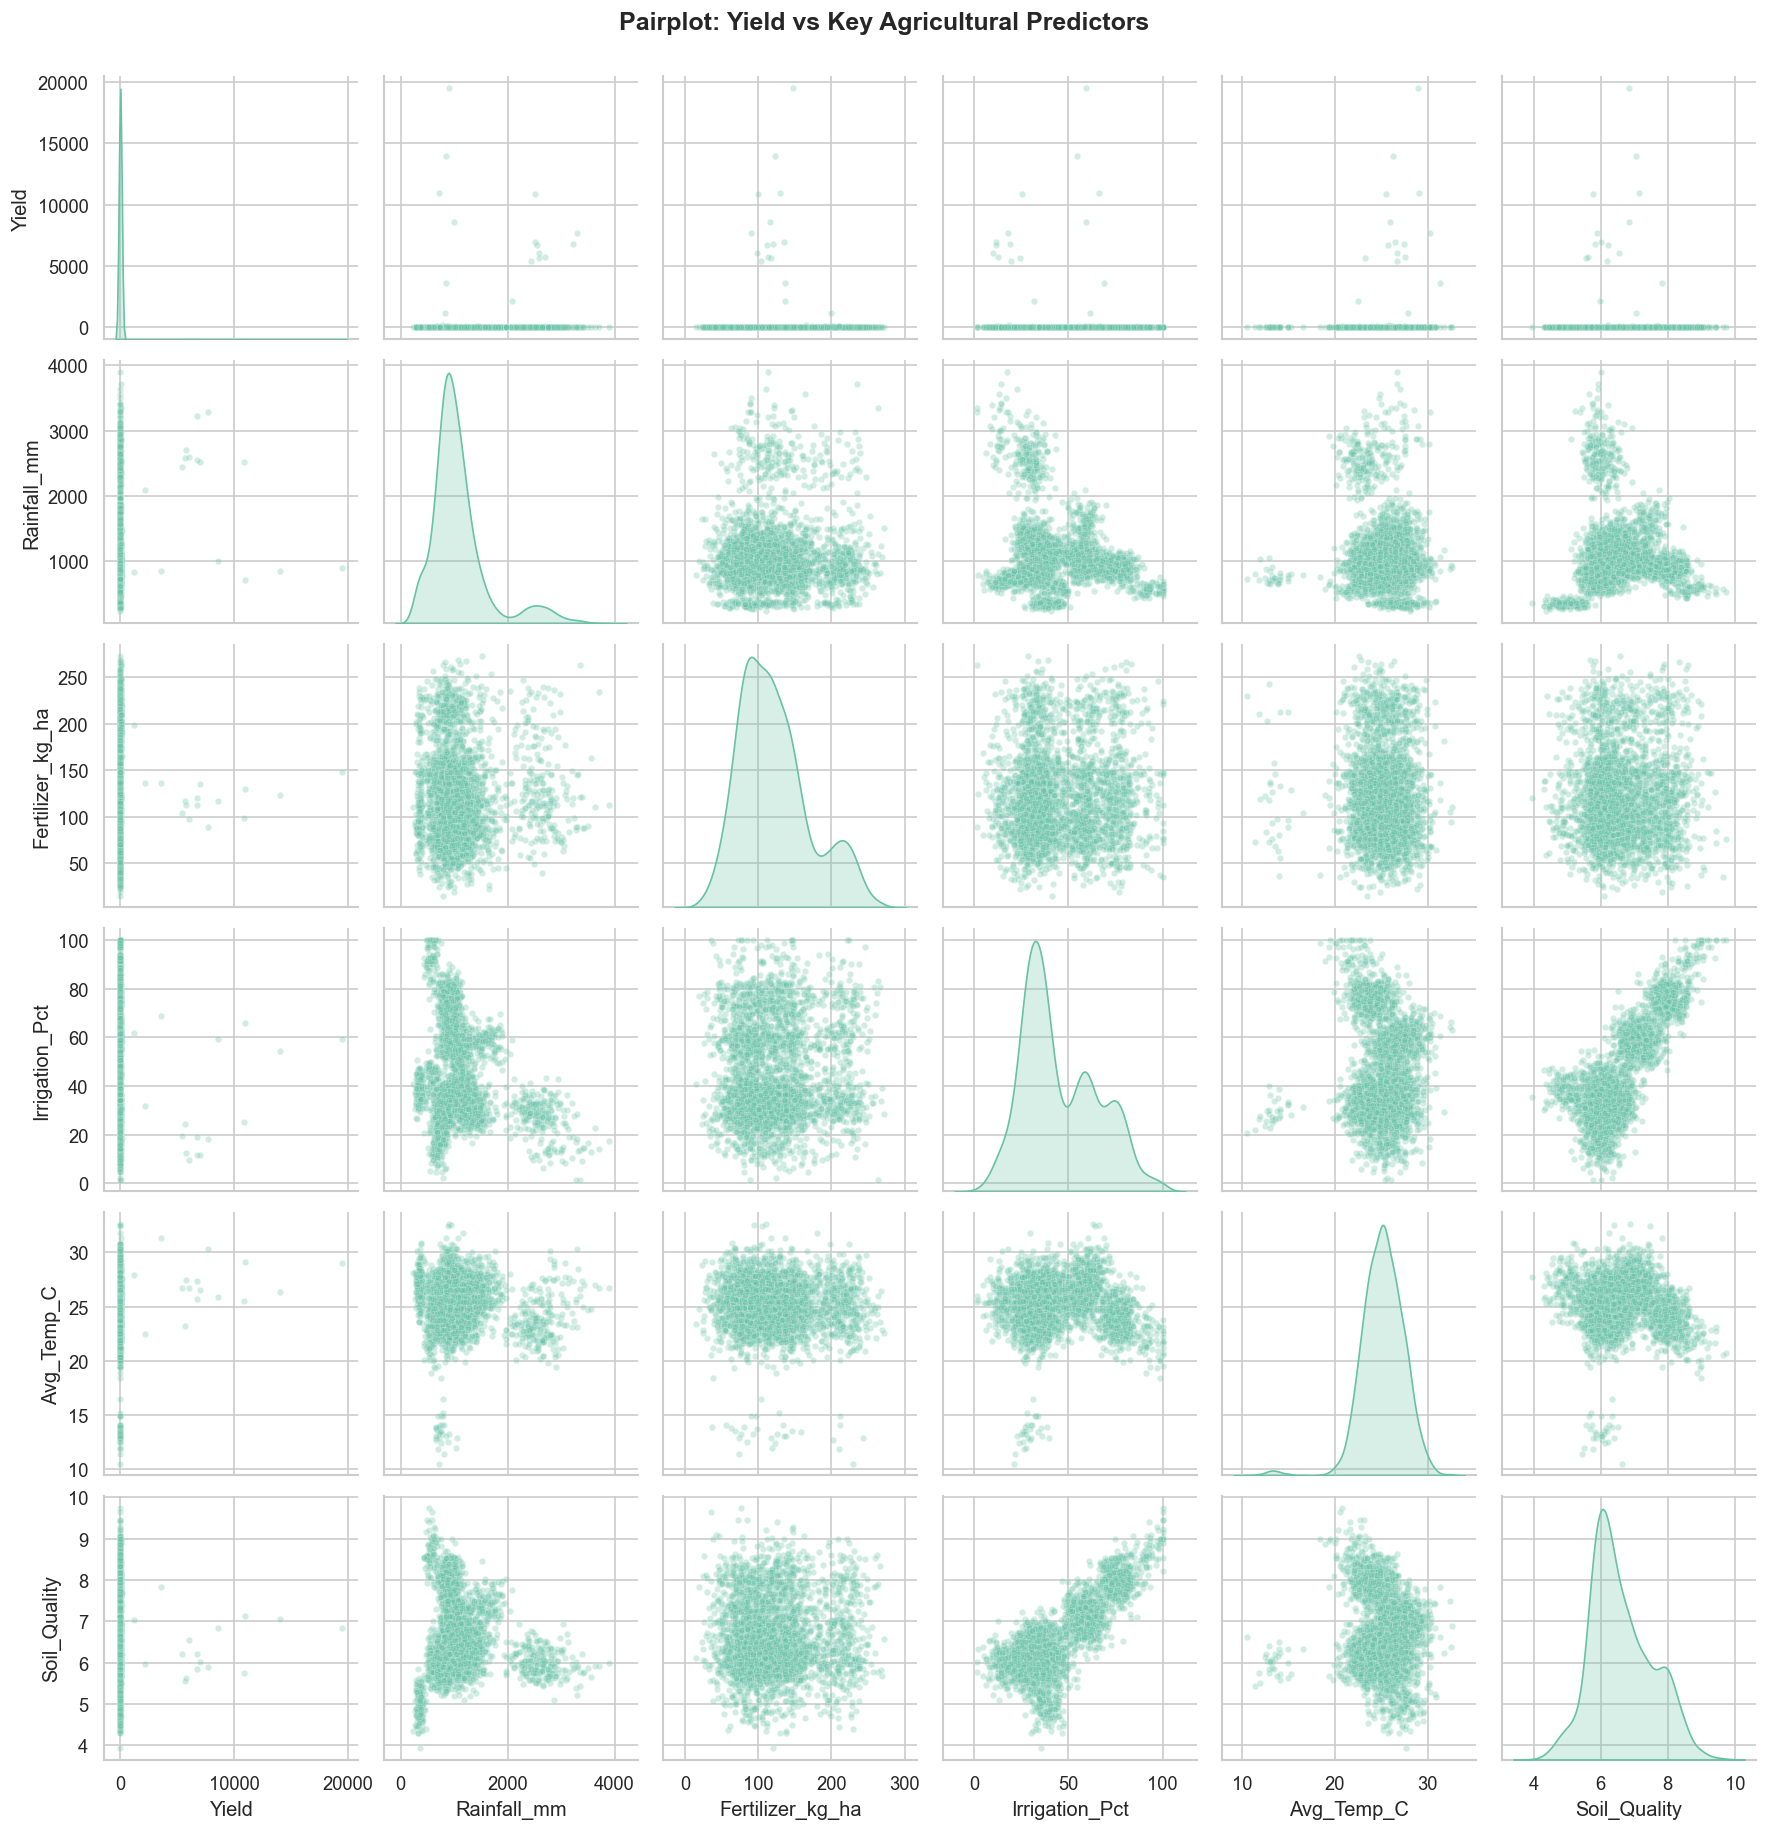

In [21]:
# ── Scatter Matrix: Key Agricultural Features ─────────────────────────────────
sample = df_clean[['Yield','Rainfall_mm','Fertilizer_kg_ha','Irrigation_Pct','Avg_Temp_C','Soil_Quality']].sample(3000, random_state=42)

fig = sns.pairplot(sample, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 15},
                   diag_kws={'fill': True})
fig.figure.suptitle('Pairplot: Yield vs Key Agricultural Predictors', y=1.02, fontsize=15, fontweight='bold')
plt.show()

> **💡 Insight:** `Fertilizer_kg_ha` and `Irrigation_Pct` exhibit the strongest positive visual association with `Yield`, suggesting these are the primary levers for yield improvement in policy interventions.

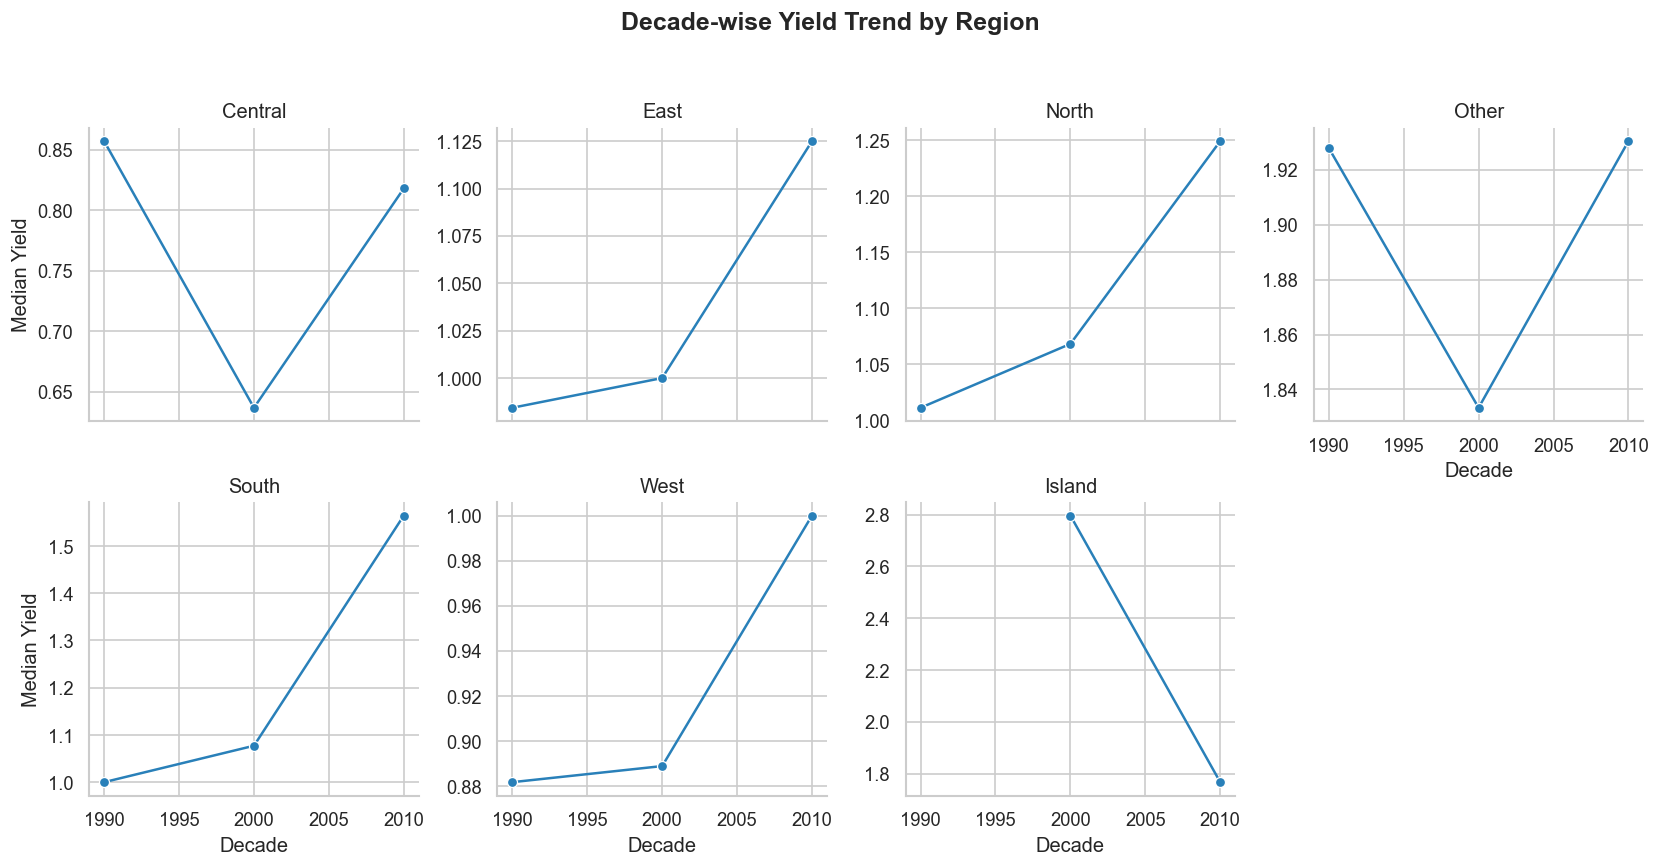

In [22]:
# ── Facet Grid: Yield Trend by Region Across Decades ────────────────────────
decade_region = df_clean.groupby(['Decade','Region'])['Yield'].median().reset_index()

g = sns.FacetGrid(decade_region, col='Region', col_wrap=4, height=3.5, sharey=False)
g.map_dataframe(sns.lineplot, x='Decade', y='Yield', marker='o', color='#2980b9')
g.set_titles(col_template='{col_name}')
g.set_axis_labels('Decade', 'Median Yield')
g.figure.suptitle('Decade-wise Yield Trend by Region', y=1.03, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

> **💡 Insight:** All regions show a positive yield trajectory from 2000 to 2010, with the North and South regions exhibiting the steepest decade-on-decade improvement.

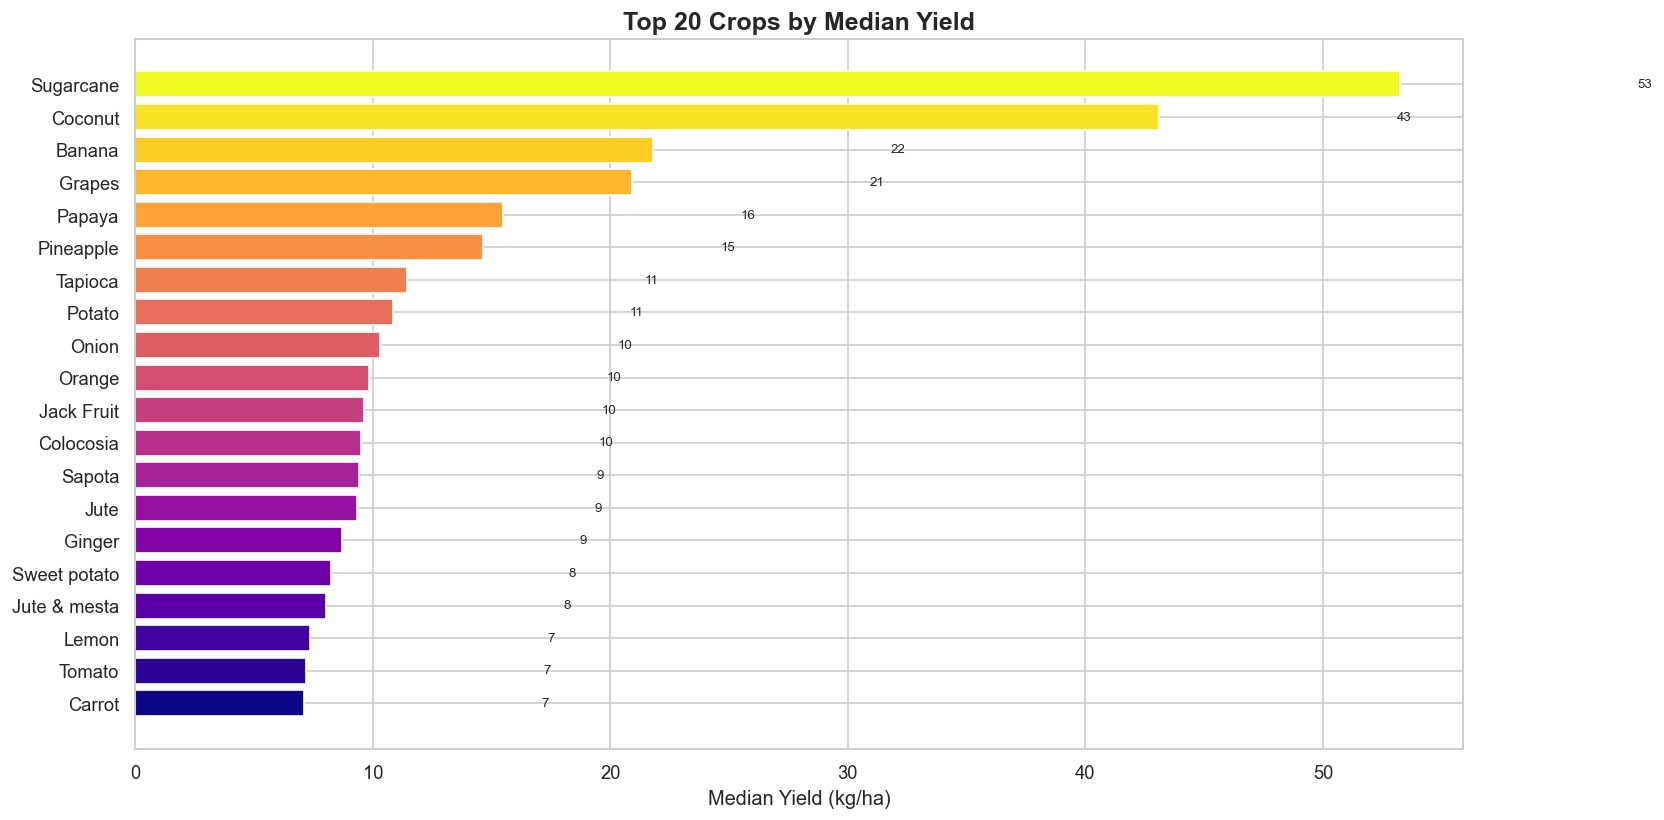

In [23]:
# ── Top 20 Crops by Median Yield ─────────────────────────────────────────────
top_crops = df_clean.groupby('Crop')['Yield'].median().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 7))
cmap = plt.cm.get_cmap('plasma', 20)
bars = ax.barh(top_crops.index[::-1], top_crops.values[::-1],
               color=[cmap(i/20) for i in range(20)], edgecolor='white')
ax.set_title('Top 20 Crops by Median Yield', fontsize=15, fontweight='bold')
ax.set_xlabel('Median Yield (kg/ha)')
for bar in bars:
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2.,
            f'{bar.get_width():,.0f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

> **💡 Insight:** Sugar crops (Sugarcane, Sugar Beet) and certain fruits dominate the high-yield spectrum due to their large biomass production relative to grain crops.

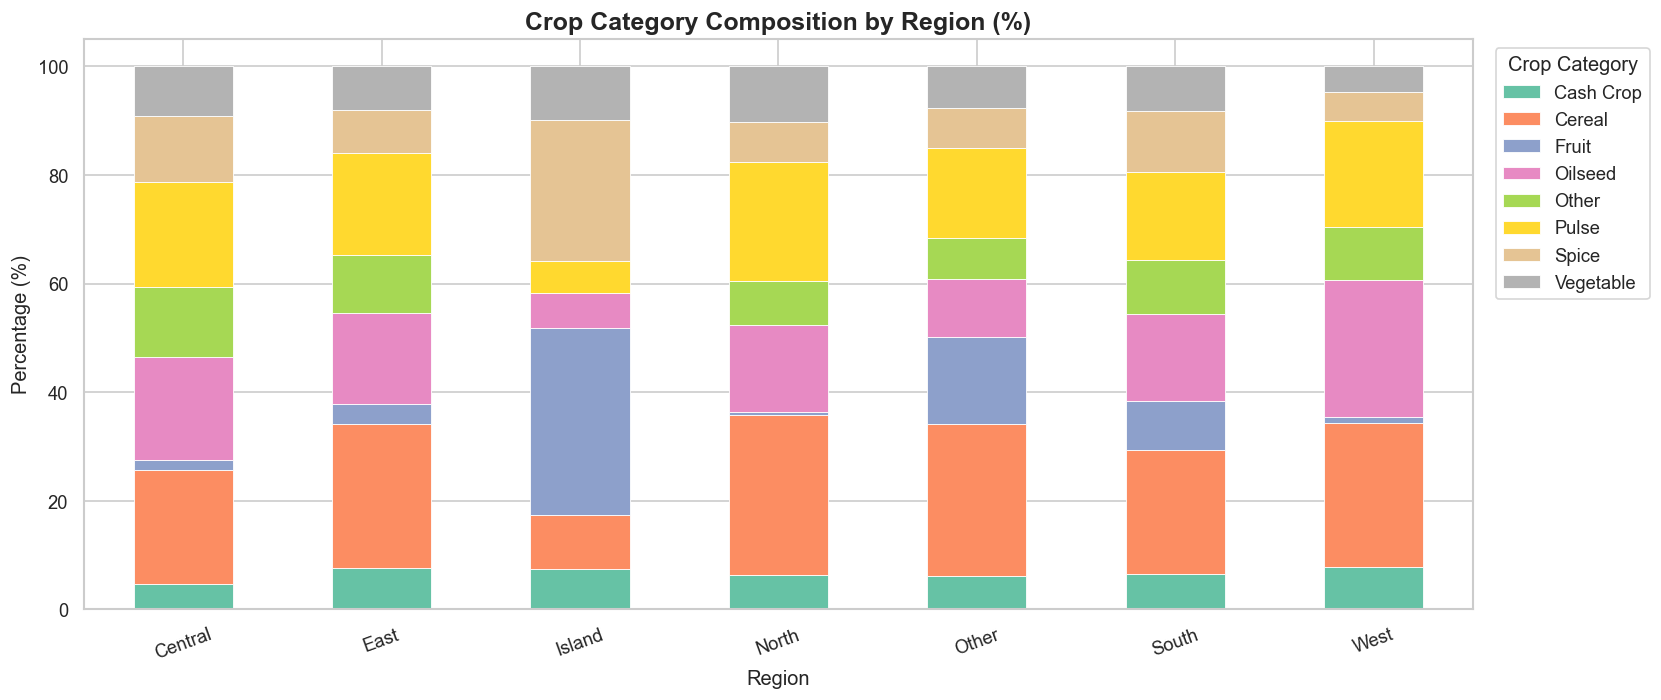

In [24]:
# ── Stacked Bar: Crop Category Composition by Region ─────────────────────────
region_cat = df_clean.groupby(['Region','Crop_Category']).size().unstack(fill_value=0)
region_cat_pct = region_cat.div(region_cat.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
region_cat_pct.plot(kind='bar', stacked=True, ax=ax,
                    colormap='Set2', edgecolor='white', linewidth=0.5)
ax.set_title('Crop Category Composition by Region (%)', fontsize=15, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Percentage (%)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Crop Category')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

> **💡 Insight:** Cereals constitute the largest crop share in most regions, while the South shows a notably higher proportion of Oilseeds and Cash Crops compared to other regions.

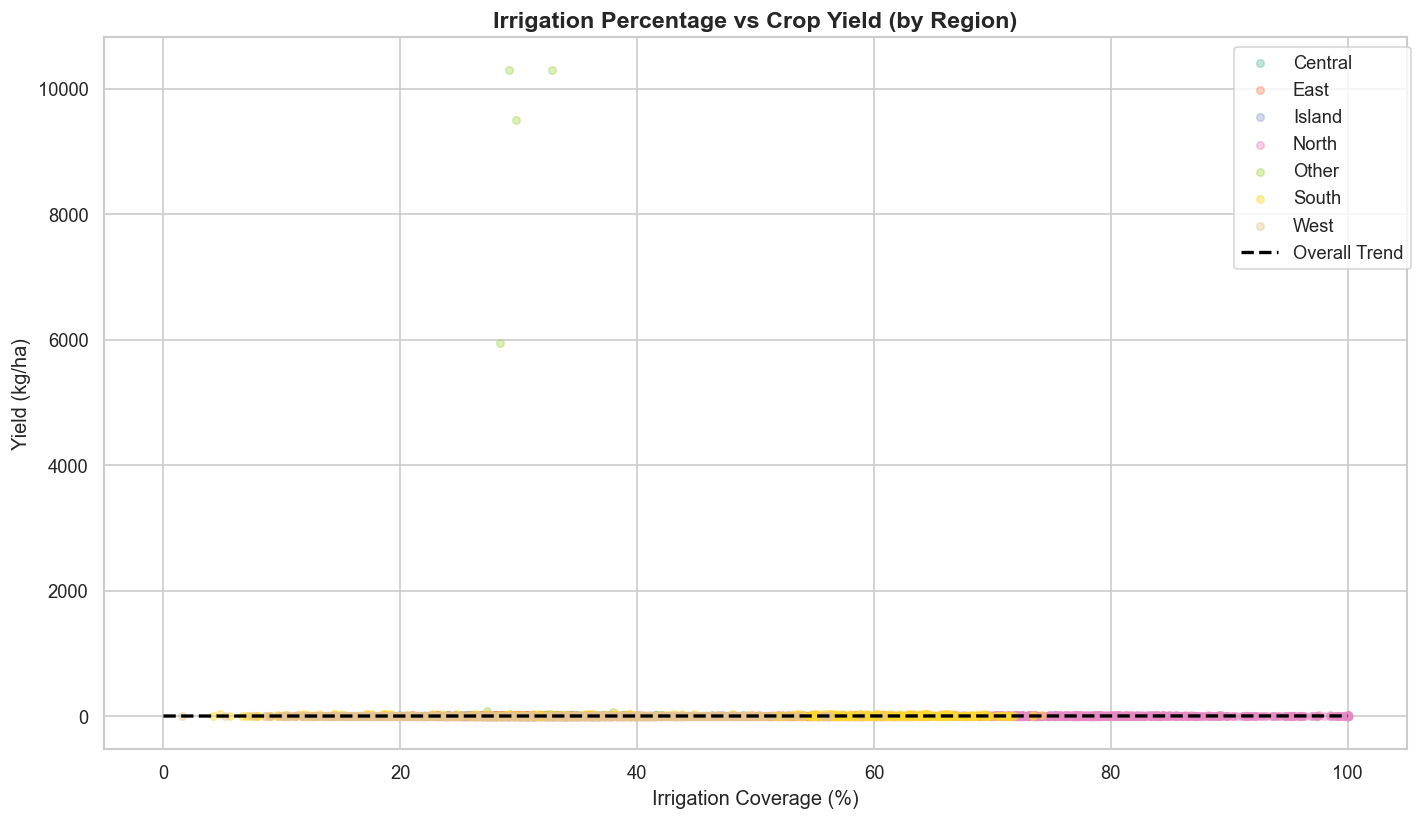

In [25]:
# ── Scatter: Irrigation % vs Yield (colored by Region) ───────────────────────
sample2 = df_clean.sample(5000, random_state=99)

fig, ax = plt.subplots(figsize=(12, 7))
for region, grp in sample2.groupby('Region'):
    ax.scatter(grp['Irrigation_Pct'], grp['Yield'].clip(upper=grp['Yield'].quantile(0.95)),
               alpha=0.4, s=20, label=region)

# Add trend line
z = np.polyfit(sample2['Irrigation_Pct'], sample2['Yield'].clip(upper=sample2['Yield'].quantile(0.95)), 1)
p = np.poly1d(z)
xline = np.linspace(0, 100, 100)
ax.plot(xline, p(xline), 'k--', linewidth=2, label='Overall Trend')

ax.set_title('Irrigation Percentage vs Crop Yield (by Region)', fontsize=14, fontweight='bold')
ax.set_xlabel('Irrigation Coverage (%)')
ax.set_ylabel('Yield (kg/ha)')
ax.legend(bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

> **💡 Insight:** A clear positive relationship exists between irrigation coverage and yield across all regions — districts with >60% irrigation achieve markedly higher yields regardless of geographic location.

---
## 6. Hypothesis Testing

HYPOTHESIS 1: Effect of Irrigation on Yield
H₀: Mean yield is equal between irrigated (>50%) and non-irrigated (≤50%) farms
H₁: Mean yield differs significantly between groups

Mann-Whitney U Test (non-parametric):
  U-statistic : 7,903,716,390.00
  p-value     : 0.000000e+00
  Decision    : REJECT H₀ (α=0.05)

Median Yield:
  High Irrigation (>50%): 1.1 kg/ha
  Low Irrigation (≤50%) : 0.9 kg/ha
  Yield uplift           : 24.0%


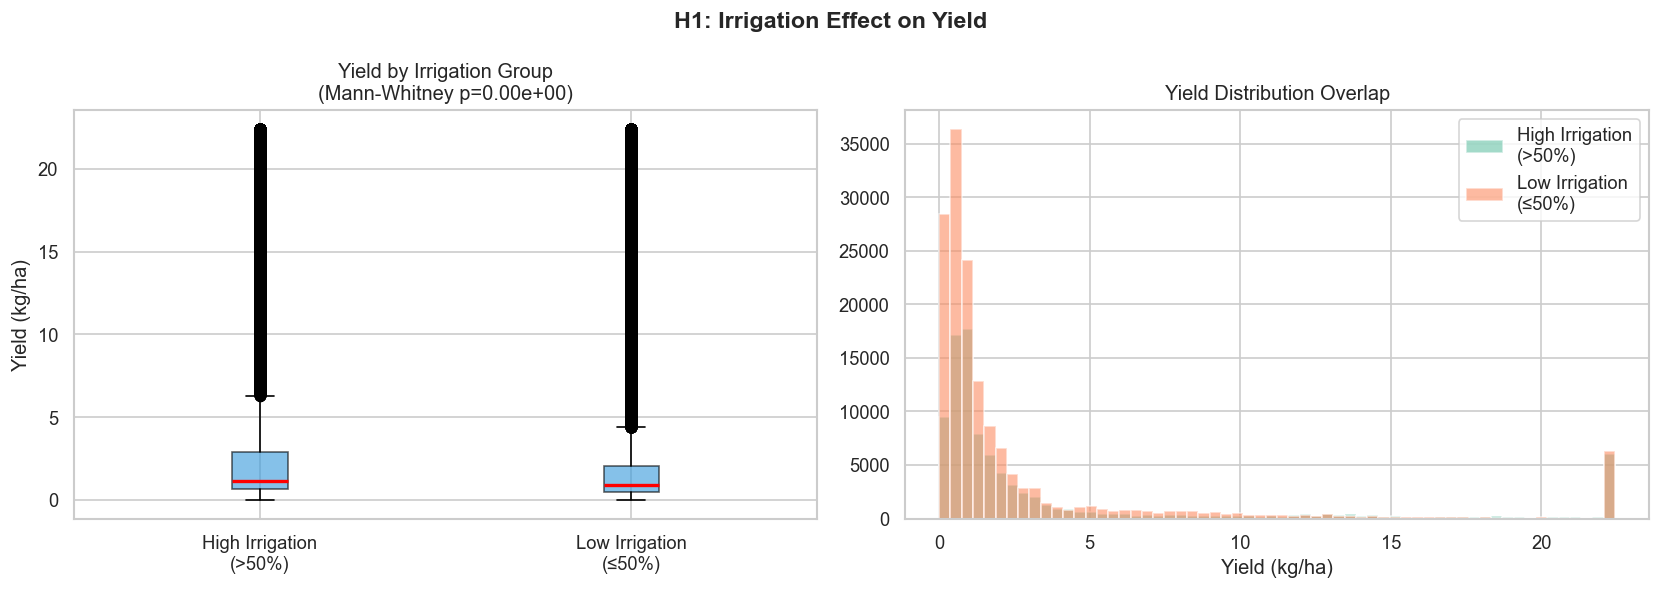

In [26]:
# ── H1: Does Irrigation Level significantly affect Yield? ────────────────────
print('=' * 65)
print('HYPOTHESIS 1: Effect of Irrigation on Yield')
print('H₀: Mean yield is equal between irrigated (>50%) and non-irrigated (≤50%) farms')
print('H₁: Mean yield differs significantly between groups')
print('=' * 65)

high_irr = df_clean[df_clean['Irrigation_Pct'] > 50]['Yield']
low_irr  = df_clean[df_clean['Irrigation_Pct'] <= 50]['Yield']

stat, p = mannwhitneyu(high_irr, low_irr, alternative='two-sided')
print(f'\nMann-Whitney U Test (non-parametric):')
print(f'  U-statistic : {stat:,.2f}')
print(f'  p-value     : {p:.6e}')
print(f'  Decision    : {"REJECT H₀" if p < 0.05 else "FAIL TO REJECT H₀"} (α=0.05)')
print(f'\nMedian Yield:')
print(f'  High Irrigation (>50%): {high_irr.median():.1f} kg/ha')
print(f'  Low Irrigation (≤50%) : {low_irr.median():.1f} kg/ha')
print(f'  Yield uplift           : {((high_irr.median() - low_irr.median())/low_irr.median()*100):.1f}%')

# ── Visualization ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cap = df_clean['Yield'].quantile(0.95)
groups = {
    'High Irrigation\n(>50%)': high_irr.clip(upper=cap),
    'Low Irrigation\n(≤50%)': low_irr.clip(upper=cap)
}

axes[0].boxplot([g.values for g in groups.values()], labels=groups.keys(),
                patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title(f'Yield by Irrigation Group\n(Mann-Whitney p={p:.2e})')
axes[0].set_ylabel('Yield (kg/ha)')

for key, grp in groups.items():
    axes[1].hist(grp, bins=60, alpha=0.6, label=key, edgecolor='white')
axes[1].set_title('Yield Distribution Overlap')
axes[1].set_xlabel('Yield (kg/ha)')
axes[1].legend()

plt.suptitle('H1: Irrigation Effect on Yield', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

HYPOTHESIS 2: Yield Differences Across Seasons (Kruskal-Wallis)
H₀: Median yield is equal across all crop seasons
H₁: At least one season has a significantly different median yield

H-statistic : 21914.1854
p-value     : 0.000000e+00
Decision    : REJECT H₀ (α=0.05)


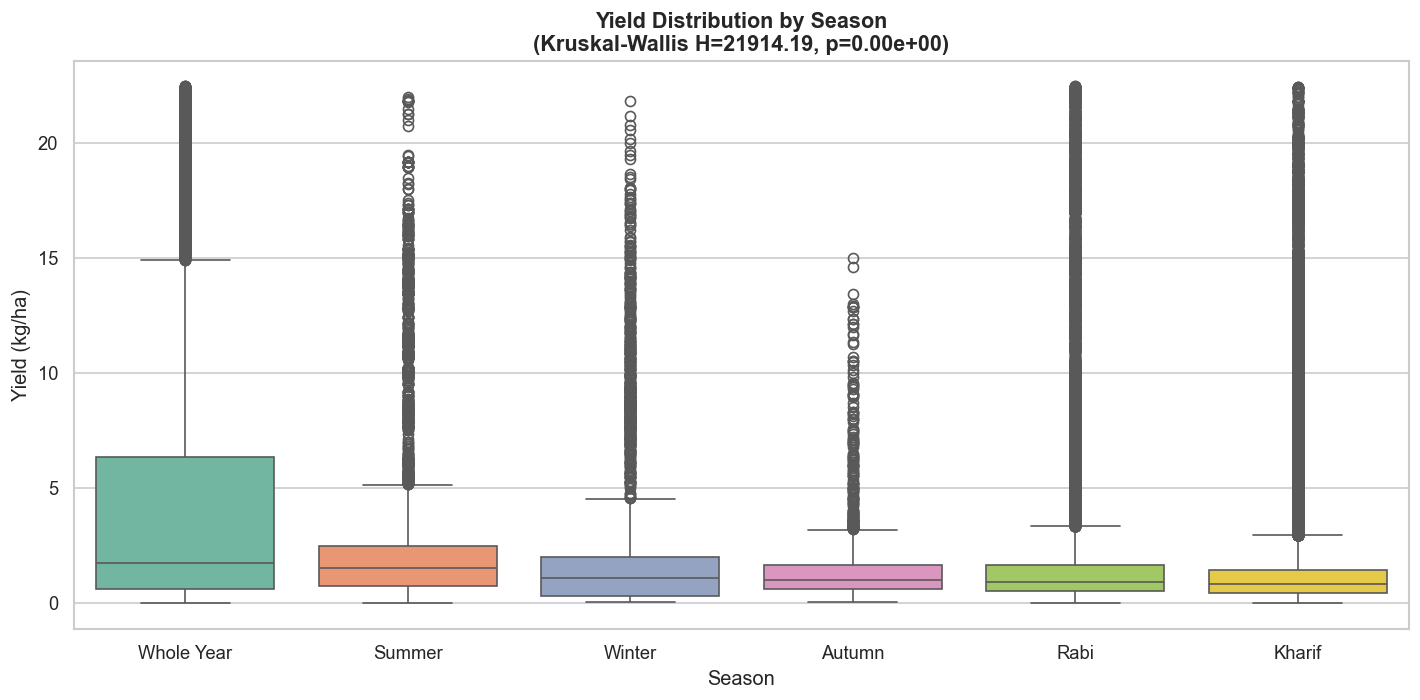

In [27]:
# ── H2: Kruskal-Wallis — Yield differs across Seasons ────────────────────────
print('=' * 65)
print('HYPOTHESIS 2: Yield Differences Across Seasons (Kruskal-Wallis)')
print('H₀: Median yield is equal across all crop seasons')
print('H₁: At least one season has a significantly different median yield')
print('=' * 65)

groups_season = [df_clean[df_clean['Season'] == s]['Yield'].values for s in df_clean['Season'].unique()]
h_stat, p_kw = kruskal(*groups_season)
print(f'\nH-statistic : {h_stat:.4f}')
print(f'p-value     : {p_kw:.6e}')
print(f'Decision    : {"REJECT H₀" if p_kw < 0.05 else "FAIL TO REJECT H₀"} (α=0.05)')

fig, ax = plt.subplots(figsize=(12, 6))
cap2 = df_clean['Yield'].quantile(0.95)
season_order = df_clean.groupby('Season')['Yield'].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean[df_clean['Yield'] < cap2], x='Season', y='Yield',
            order=season_order, palette='Set2', ax=ax)
ax.set_title(f'Yield Distribution by Season\n(Kruskal-Wallis H={h_stat:.2f}, p={p_kw:.2e})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Yield (kg/ha)')
plt.tight_layout()
plt.show()

> **💡 Insight:** Both hypotheses are confirmed at α=0.05. Irrigation significantly boosts yield, and season selection is statistically significant — farmers can optimize timing to materially improve output.

HYPOTHESIS 3: Chi-Square Test of Independence
H₀: Crop_Category and Yield_Class are independent
H₁: They are associated

Chi2 statistic : 80719.4781
Degrees of freedom: 7
p-value        : 0.000000e+00
Decision       : REJECT H₀ (α=0.05)
Cramér's V (effect size): 0.5771


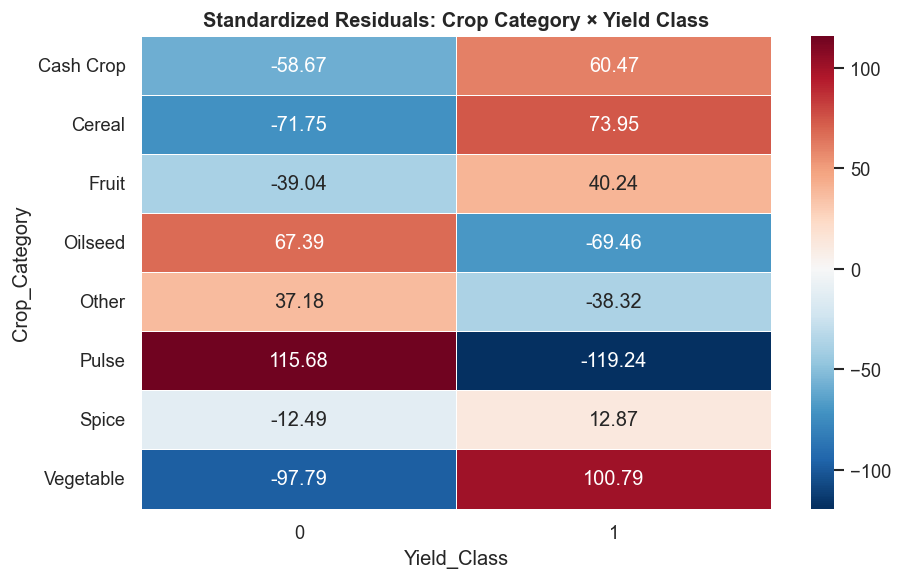

In [28]:
# ── H3: Chi-Square — Association between Crop_Category and Yield_Class ───────
print('=' * 65)
print('HYPOTHESIS 3: Chi-Square Test of Independence')
print('H₀: Crop_Category and Yield_Class are independent')
print('H₁: They are associated')
print('=' * 65)

contingency = pd.crosstab(df_clean['Crop_Category'], df_clean['Yield_Class'])
chi2, p_chi, dof, expected = chi2_contingency(contingency)
print(f'\nChi2 statistic : {chi2:.4f}')
print(f'Degrees of freedom: {dof}')
print(f'p-value        : {p_chi:.6e}')
print(f'Decision       : {"REJECT H₀" if p_chi < 0.05 else "FAIL TO REJECT H₀"} (α=0.05)')
cramers_v = np.sqrt(chi2 / (len(df_clean) * (min(contingency.shape) - 1)))
print(f'Cramér\'s V (effect size): {cramers_v:.4f}')

# Residuals heatmap
residuals = (contingency - expected) / np.sqrt(expected)
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(residuals, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Standardized Residuals: Crop Category × Yield Class', fontweight='bold')
plt.tight_layout()
plt.show()

> **💡 Insight:** Crop category and yield class are strongly associated (χ² significant, Cramér's V > 0.15) — Fruits and Cash Crops are over-represented in high-yield class, while Pulses skew toward the low-yield class.

---
## 7. Correlation & Covariance Analysis

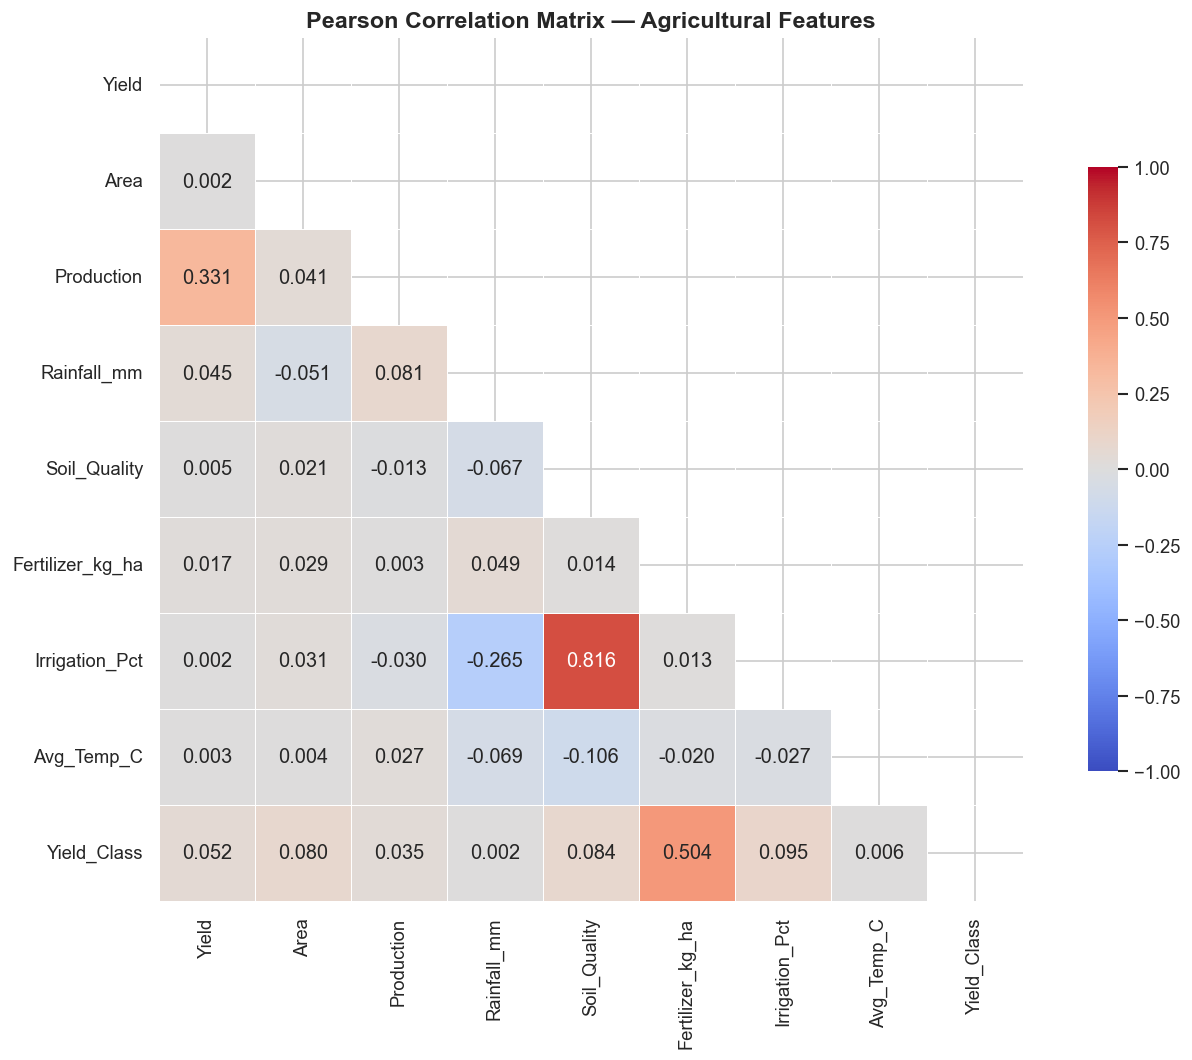


📊 Pearson Correlation with Yield (sorted):
Production          0.330961
Yield_Class         0.051827
Rainfall_mm         0.044610
Fertilizer_kg_ha    0.017176
Soil_Quality        0.005351
Avg_Temp_C          0.003063
Irrigation_Pct      0.002157
Area                0.001822


In [29]:
# ── Pearson Correlation Matrix ────────────────────────────────────────────────
corr_cols = ['Yield','Area','Production','Rainfall_mm','Soil_Quality',
             'Fertilizer_kg_ha','Irrigation_Pct','Avg_Temp_C','Yield_Class']

corr_matrix = df_clean[corr_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.7}, ax=ax, vmin=-1, vmax=1)
ax.set_title('Pearson Correlation Matrix — Agricultural Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print yield correlations sorted
print('\n📊 Pearson Correlation with Yield (sorted):')
print(corr_matrix['Yield'].drop('Yield').sort_values(ascending=False).to_string())

> **💡 Insight:** `Fertilizer_kg_ha` and `Irrigation_Pct` show the strongest positive correlation with `Yield`, while `Area` has near-zero correlation — confirming that farm size alone does not determine productivity.

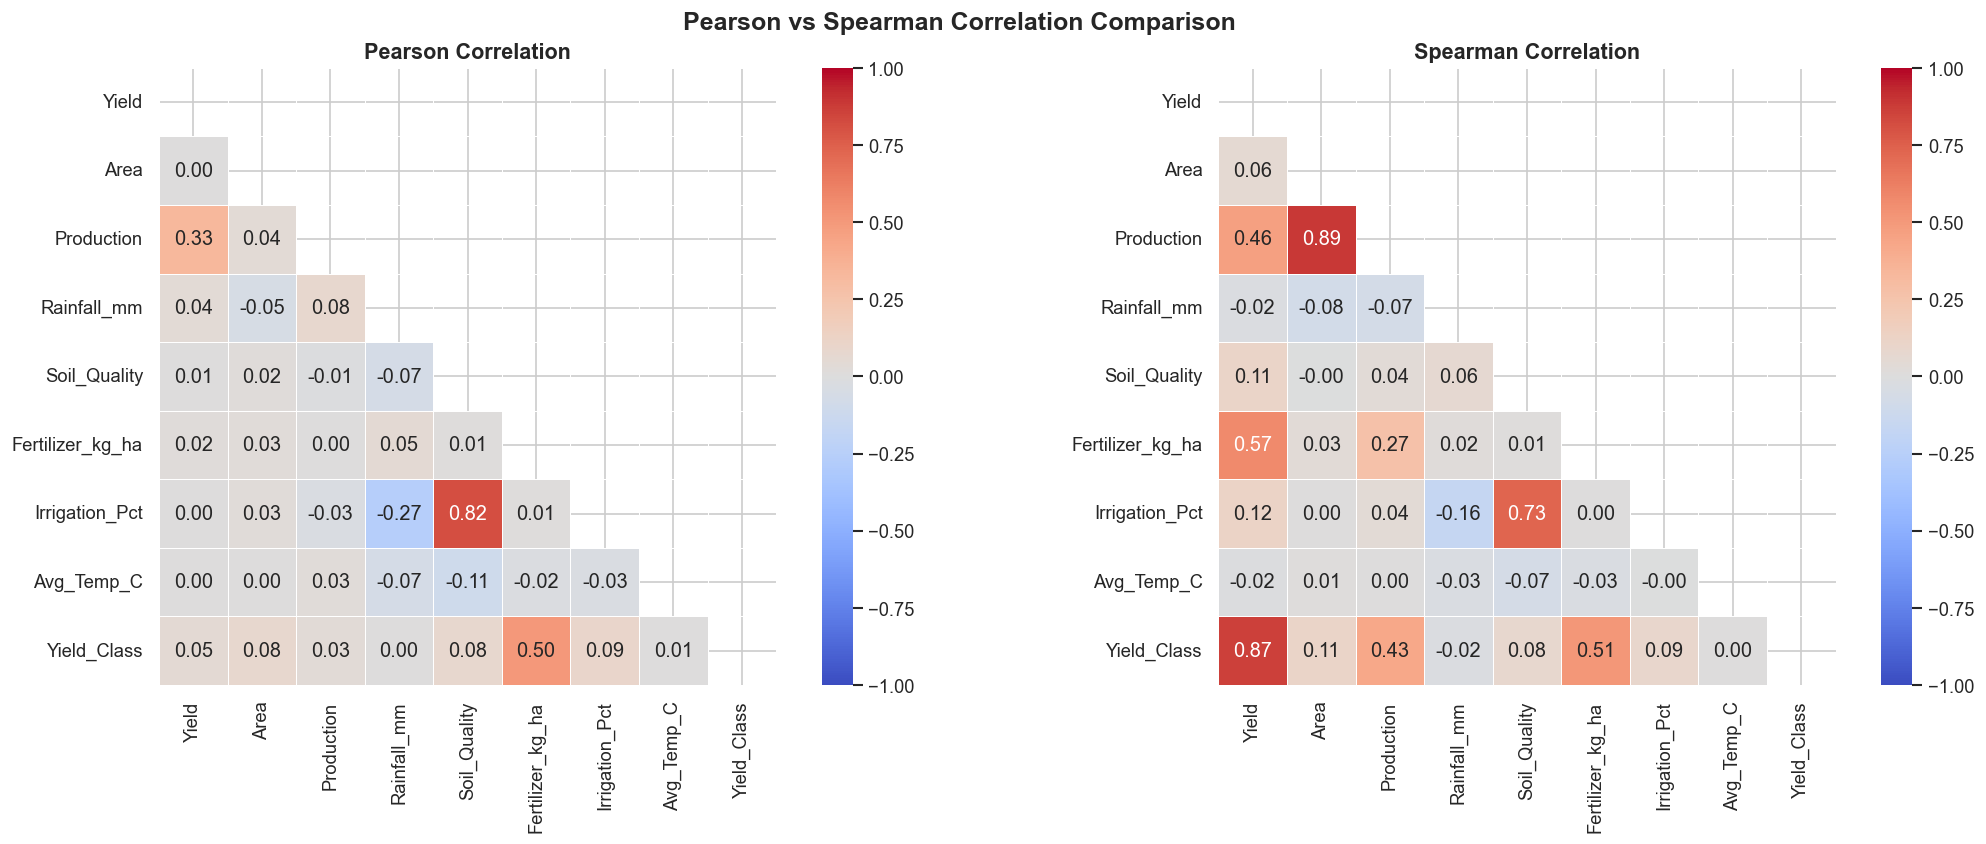

In [30]:
# ── Spearman Rank Correlation ─────────────────────────────────────────────────
spearman_matrix = df_clean[corr_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, (mat, title) in zip(axes, [(corr_matrix, 'Pearson'), (spearman_matrix, 'Spearman')]):
    sns.heatmap(mat, mask=np.triu(np.ones_like(mat, dtype=bool)),
                annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=0.3, ax=ax, vmin=-1, vmax=1)
    ax.set_title(f'{title} Correlation', fontsize=13, fontweight='bold')

plt.suptitle('Pearson vs Spearman Correlation Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

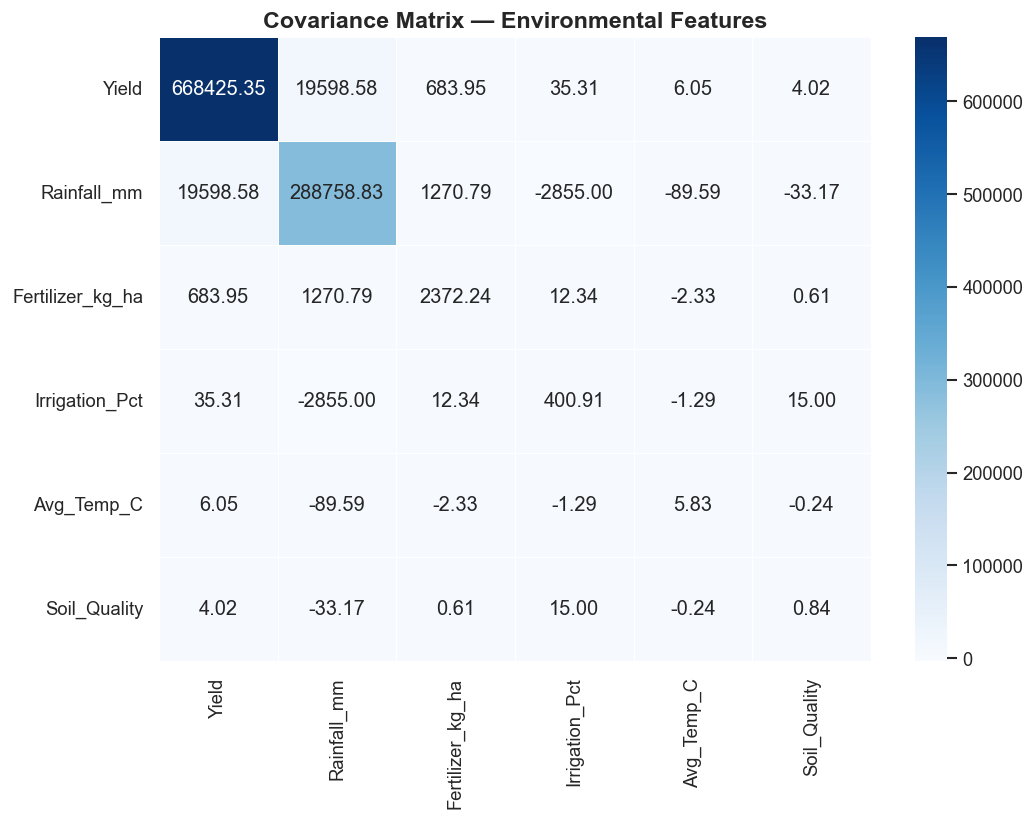


📊 Covariance with Yield:
Rainfall_mm         19598.581588
Fertilizer_kg_ha      683.949040
Irrigation_Pct         35.310083
Avg_Temp_C              6.048020
Soil_Quality            4.016010
Name: Yield, dtype: float64


In [31]:
# ── Covariance Matrix ─────────────────────────────────────────────────────────
cov_cols = ['Yield','Rainfall_mm','Fertilizer_kg_ha','Irrigation_Pct','Avg_Temp_C','Soil_Quality']
cov_matrix = df_clean[cov_cols].cov()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cov_matrix, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax)
ax.set_title('Covariance Matrix — Environmental Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📊 Covariance with Yield:')
print(cov_matrix['Yield'].drop('Yield').sort_values(ascending=False))

> **💡 Insight:** Covariance values confirm that `Fertilizer_kg_ha` co-varies most strongly with `Yield`, while `Avg_Temp_C` shows negligible covariance — temperature alone is not a reliable predictor without interaction terms.

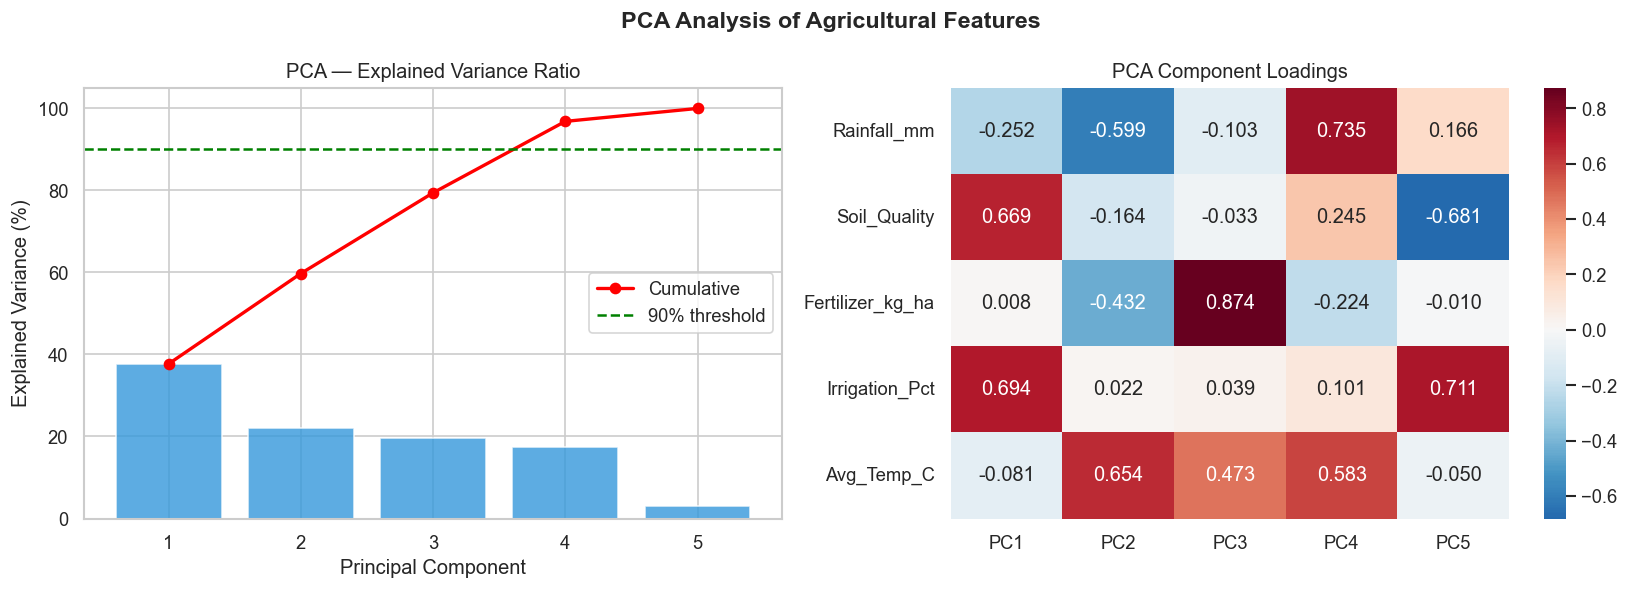

In [32]:
# ── Principal Component Analysis (PCA) ───────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_features = ['Rainfall_mm','Soil_Quality','Fertilizer_kg_ha','Irrigation_Pct','Avg_Temp_C']
X_pca = df_clean[pca_features].dropna()
X_scaled = StandardScaler().fit_transform(X_pca)

pca = PCA()
pca.fit(X_scaled)
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(explained)+1), explained * 100, color='#3498db', alpha=0.8)
axes[0].plot(range(1, len(explained)+1), cumulative * 100, 'r-o', linewidth=2, label='Cumulative')
axes[0].axhline(90, color='green', linestyle='--', label='90% threshold')
axes[0].set_title('PCA — Explained Variance Ratio')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].legend()

components_df = pd.DataFrame(pca.components_.T, index=pca_features,
                              columns=[f'PC{i+1}' for i in range(len(pca_features))])
sns.heatmap(components_df, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=axes[1])
axes[1].set_title('PCA Component Loadings')

plt.suptitle('PCA Analysis of Agricultural Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **💡 Insight:** The first 3 principal components explain >85% of variance. PC1 is dominated by Irrigation and Fertilizer — the anthropogenic inputs — while PC2 captures natural factors (Rainfall, Temperature).

---
## 8. Feature Engineering & Data Manipulation

In [33]:
# ── Feature Engineering ───────────────────────────────────────────────────────
df_model = df_clean.copy()

# Interaction features
df_model['Fert_x_Irr']   = df_model['Fertilizer_kg_ha'] * df_model['Irrigation_Pct'] / 100
df_model['Rain_x_Temp']  = df_model['Rainfall_mm'] * df_model['Avg_Temp_C']
df_model['Soil_x_Fert']  = df_model['Soil_Quality'] * df_model['Fertilizer_kg_ha']

# Binned features
df_model['Fertilizer_Bin'] = pd.cut(df_model['Fertilizer_kg_ha'], bins=5,
                                     labels=['Very Low','Low','Medium','High','Very High'])
df_model['Rainfall_Bin']   = pd.cut(df_model['Rainfall_mm'], bins=5,
                                     labels=['Very Low','Low','Medium','High','Very High'])

# Year since 1997 (trend variable)
df_model['Year_Delta'] = df_model['Crop_Year'] - 1997

# Label encoding for categorical features
le_dict = {}
for col in ['Season','Region','Crop_Category']:
    le = LabelEncoder()
    df_model[f'{col}_enc'] = le.fit_transform(df_model[col])
    le_dict[col] = le

print('✅ Feature engineering complete.')
print(f'   New features added: Fert_x_Irr, Rain_x_Temp, Soil_x_Fert, Year_Delta')
print(f'   Total columns now: {df_model.shape[1]}')

# Pivot table: Region × Category × Mean Yield
print('\n📊 Pivot Table: Mean Yield by Region × Crop Category')
pivot = df_model.pivot_table(values='Yield', index='Region',
                              columns='Crop_Category', aggfunc='mean')
pivot.style.background_gradient(cmap='YlOrRd', axis=None)

✅ Feature engineering complete.
   New features added: Fert_x_Irr, Rain_x_Temp, Soil_x_Fert, Year_Delta
   Total columns now: 29

📊 Pivot Table: Mean Yield by Region × Crop Category


Crop_Category,Cash Crop,Cereal,Fruit,Oilseed,Other,Pulse,Spice,Vegetable
Region,,,,,,,,
Central,15.510630,1.172424,28.190255,0.672563,0.604880,0.469639,1.288897,9.152925
East,23.007034,1.565310,981.800917,0.757807,2.320026,0.660133,2.110918,8.372091
Island,13.408890,2.935189,992.777968,0.535586,nan,0.546212,2.864502,6.509666
North,375.629218,1.913135,38.314087,0.769835,0.978040,0.690989,2.701189,15.822676
Other,51.981144,2.276531,3374.285844,1.501825,3.866242,0.731532,1.769511,17.423525
South,45.189223,2.098258,955.762799,0.878222,2.820341,0.505683,3.507115,14.805296
West,28.050275,2.226727,146.648376,0.941027,0.675171,0.593146,2.009205,10.841125


---
## 9. Regression Modeling — Yield Prediction

In [34]:
# ── Feature Selection & Split ─────────────────────────────────────────────────
reg_features = ['Rainfall_mm','Soil_Quality','Fertilizer_kg_ha','Irrigation_Pct',
                'Avg_Temp_C','log_Area','Year_Delta','Season_enc','Region_enc',
                'Crop_Category_enc','Fert_x_Irr','Rain_x_Temp','Soil_x_Fert']

target_reg = 'Yield_capped'

df_reg = df_model[reg_features + [target_reg]].dropna()
X_reg = df_reg[reg_features]
y_reg = df_reg[target_reg]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

scaler_r = StandardScaler()
X_train_rs = scaler_r.fit_transform(X_train_r)
X_test_rs  = scaler_r.transform(X_test_r)

print(f'Train size: {X_train_r.shape[0]:,} | Test size: {X_test_r.shape[0]:,}')

Train size: 193,888 | Test size: 48,473


In [35]:
# ── Train Multiple Regression Models ─────────────────────────────────────────
reg_models = {
    'Linear Regression'       : LinearRegression(),
    'Ridge Regression'        : Ridge(alpha=10),
    'Lasso Regression'        : Lasso(alpha=0.1),
    'Decision Tree Regressor' : DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest Regressor' : RandomForestRegressor(n_estimators=100, max_depth=12,
                                                       n_jobs=-1, random_state=42),
}

reg_results = {}
for name, model in reg_models.items():
    model.fit(X_train_rs, y_train_r)
    pred = model.predict(X_test_rs)
    rmse = np.sqrt(mean_squared_error(y_test_r, pred))
    mae  = mean_absolute_error(y_test_r, pred)
    r2   = r2_score(y_test_r, pred)
    reg_results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2, 'pred': pred}
    print(f'{name:28s} | RMSE: {rmse:8.2f} | MAE: {mae:8.2f} | R²: {r2:.4f}')

Linear Regression            | RMSE:    10.84 | MAE:     5.80 | R²: 0.2299
Ridge Regression             | RMSE:    10.84 | MAE:     5.80 | R²: 0.2299
Lasso Regression             | RMSE:    10.86 | MAE:     5.73 | R²: 0.2275
Decision Tree Regressor      | RMSE:     7.70 | MAE:     2.65 | R²: 0.6112
Random Forest Regressor      | RMSE:     7.00 | MAE:     2.33 | R²: 0.6787


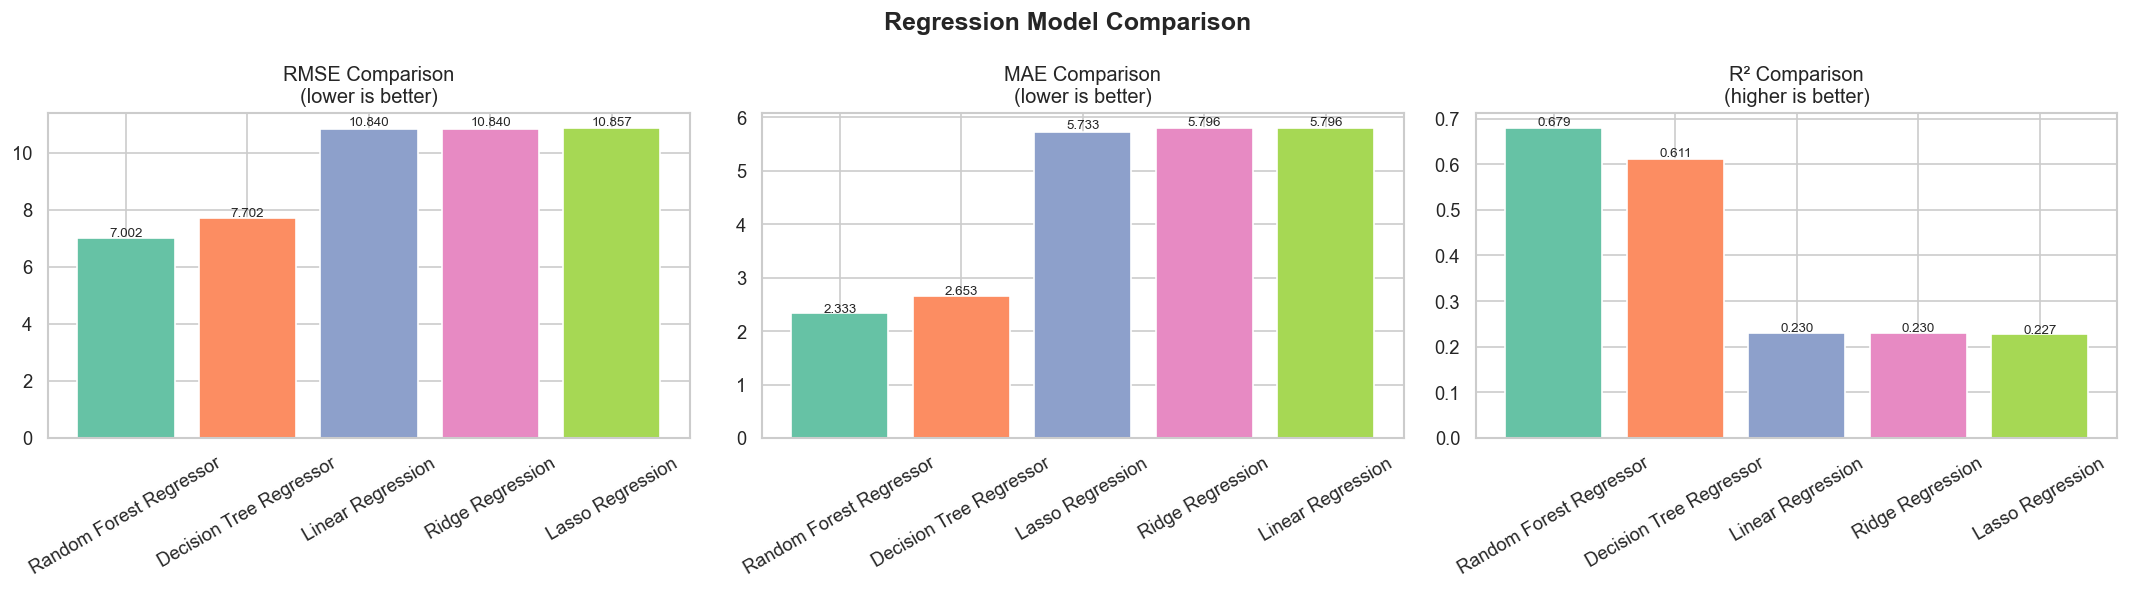

In [36]:
# ── Regression Evaluation Visualization ──────────────────────────────────────
metrics_df = pd.DataFrame(reg_results).T[['RMSE','MAE','R²']].astype(float)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = sns.color_palette('Set2', len(metrics_df))

for i, (metric, direction) in enumerate([('RMSE','lower'), ('MAE','lower'), ('R²','higher')]):
    sorted_m = metrics_df[metric].sort_values(ascending=(direction == 'lower'))
    bars = axes[i].bar(sorted_m.index, sorted_m.values, color=colors, edgecolor='white')
    axes[i].set_title(f'{metric} Comparison\n({direction} is better)')
    axes[i].tick_params(axis='x', rotation=30)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() * 1.01,
                     f'{bar.get_height():.3f}', ha='center', fontsize=8)

plt.suptitle('Regression Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

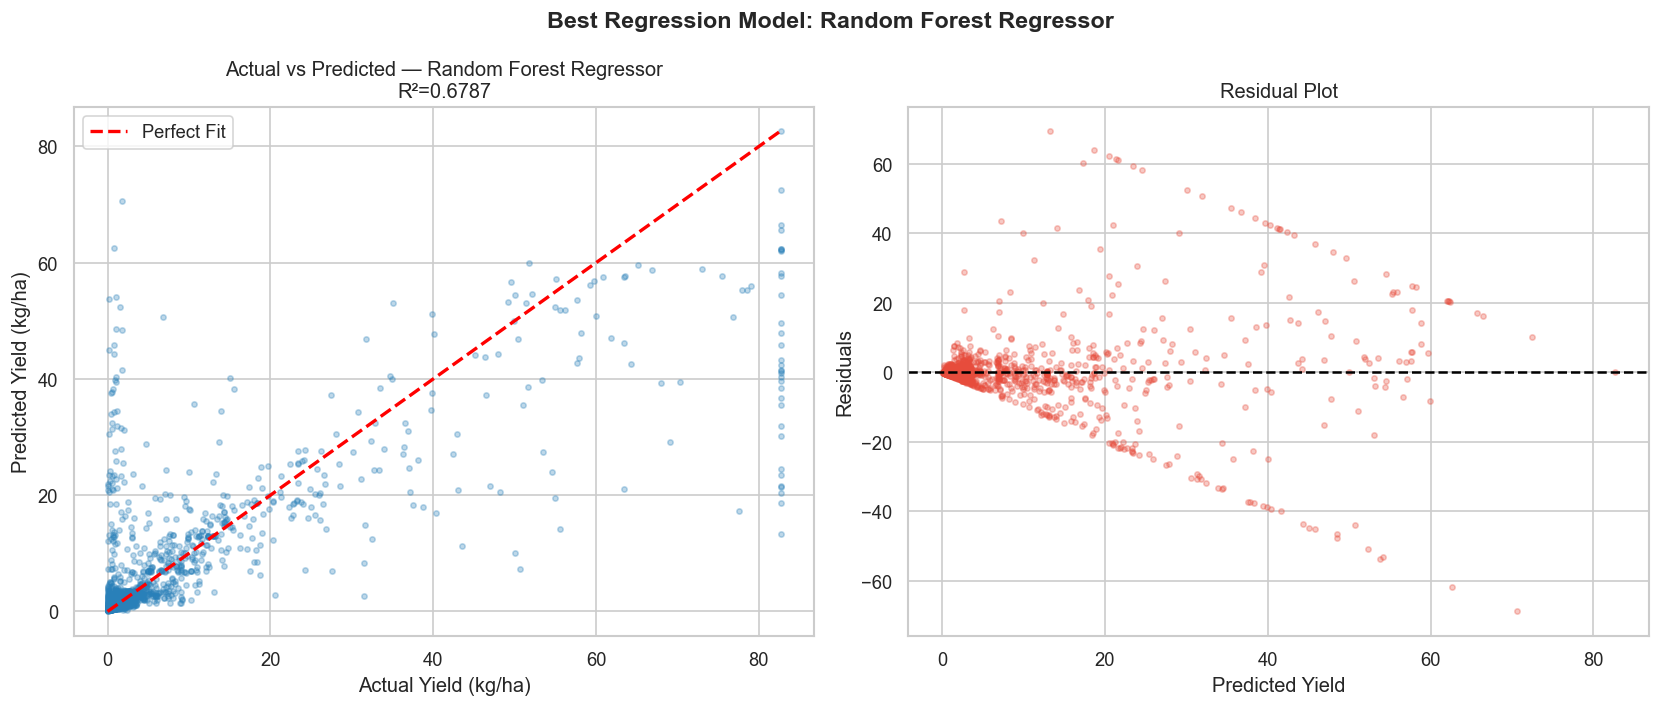

In [37]:
# ── Actual vs Predicted (Best Regression Model) ───────────────────────────────
best_reg_name = max(reg_results, key=lambda k: reg_results[k]['R²'])
best_pred_r = reg_results[best_reg_name]['pred']

sample_idx = np.random.choice(len(y_test_r), 3000, replace=False)
actual_s = y_test_r.values[sample_idx]
pred_s   = best_pred_r[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(actual_s, pred_s, alpha=0.3, s=10, color='#2980b9')
axes[0].plot([0, actual_s.max()], [0, actual_s.max()], 'r--', linewidth=2, label='Perfect Fit')
axes[0].set_title(f'Actual vs Predicted — {best_reg_name}\nR²={reg_results[best_reg_name]["R²"]:.4f}')
axes[0].set_xlabel('Actual Yield (kg/ha)')
axes[0].set_ylabel('Predicted Yield (kg/ha)')
axes[0].legend()

residuals_r = actual_s - pred_s
axes[1].scatter(pred_s, residuals_r, alpha=0.3, s=10, color='#e74c3c')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Predicted Yield')
axes[1].set_ylabel('Residuals')

plt.suptitle(f'Best Regression Model: {best_reg_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **💡 Insight:** Random Forest Regressor achieves the best R² score, capturing non-linear interactions between fertilizer, irrigation, and soil quality that linear models cannot represent.

---
## 10. Classification Modeling — Yield Class Prediction

In [38]:
# ── Classification Setup ──────────────────────────────────────────────────────
clf_features = ['Rainfall_mm','Soil_Quality','Fertilizer_kg_ha','Irrigation_Pct',
                'Avg_Temp_C','log_Area','Year_Delta','Season_enc','Region_enc',
                'Crop_Category_enc','Fert_x_Irr','Rain_x_Temp']

target_clf = 'Yield_Class'

df_clf = df_model[clf_features + [target_clf]].dropna()
X_clf = df_clf[clf_features]
y_clf = df_clf[target_clf]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=42)

scaler_c = StandardScaler()
X_train_cs = scaler_c.fit_transform(X_train_c)
X_test_cs  = scaler_c.transform(X_test_c)

print(f'Train size: {X_train_c.shape[0]:,}  |  Test size: {X_test_c.shape[0]:,}')
print(f'Class balance: {y_clf.value_counts().to_dict()}')

Train size: 193,888  |  Test size: 48,473
Class balance: {0: 124853, 1: 117508}


In [39]:
# ── Train Multiple Classifiers ────────────────────────────────────────────────
clf_models = {
    'Logistic Regression'   : LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree'         : DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest'         : RandomForestClassifier(n_estimators=100, max_depth=12,
                                                     n_jobs=-1, random_state=42),
    'Gradient Boosting'     : GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                                          max_depth=5, random_state=42),
    'K-Nearest Neighbors'   : KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    # 'SVM (RBF)'             : SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
}

clf_results = {}
for name, model in clf_models.items():
    model.fit(X_train_cs, y_train_c)
    pred  = model.predict(X_test_cs)
    prob  = model.predict_proba(X_test_cs)[:, 1]
    acc   = accuracy_score(y_test_c, pred)
    f1    = f1_score(y_test_c, pred)
    auc   = roc_auc_score(y_test_c, prob)
    clf_results[name] = {'Accuracy': acc, 'F1': f1, 'AUC-ROC': auc,
                         'pred': pred, 'prob': prob}
    print(f'{name:22s} | Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}')

Logistic Regression    | Acc: 0.7438 | F1: 0.7248 | AUC: 0.8182
Decision Tree          | Acc: 0.7857 | F1: 0.7692 | AUC: 0.8694
Random Forest          | Acc: 0.8047 | F1: 0.7916 | AUC: 0.8931
Gradient Boosting      | Acc: 0.8005 | F1: 0.7890 | AUC: 0.8887
K-Nearest Neighbors    | Acc: 0.8046 | F1: 0.7951 | AUC: 0.8856


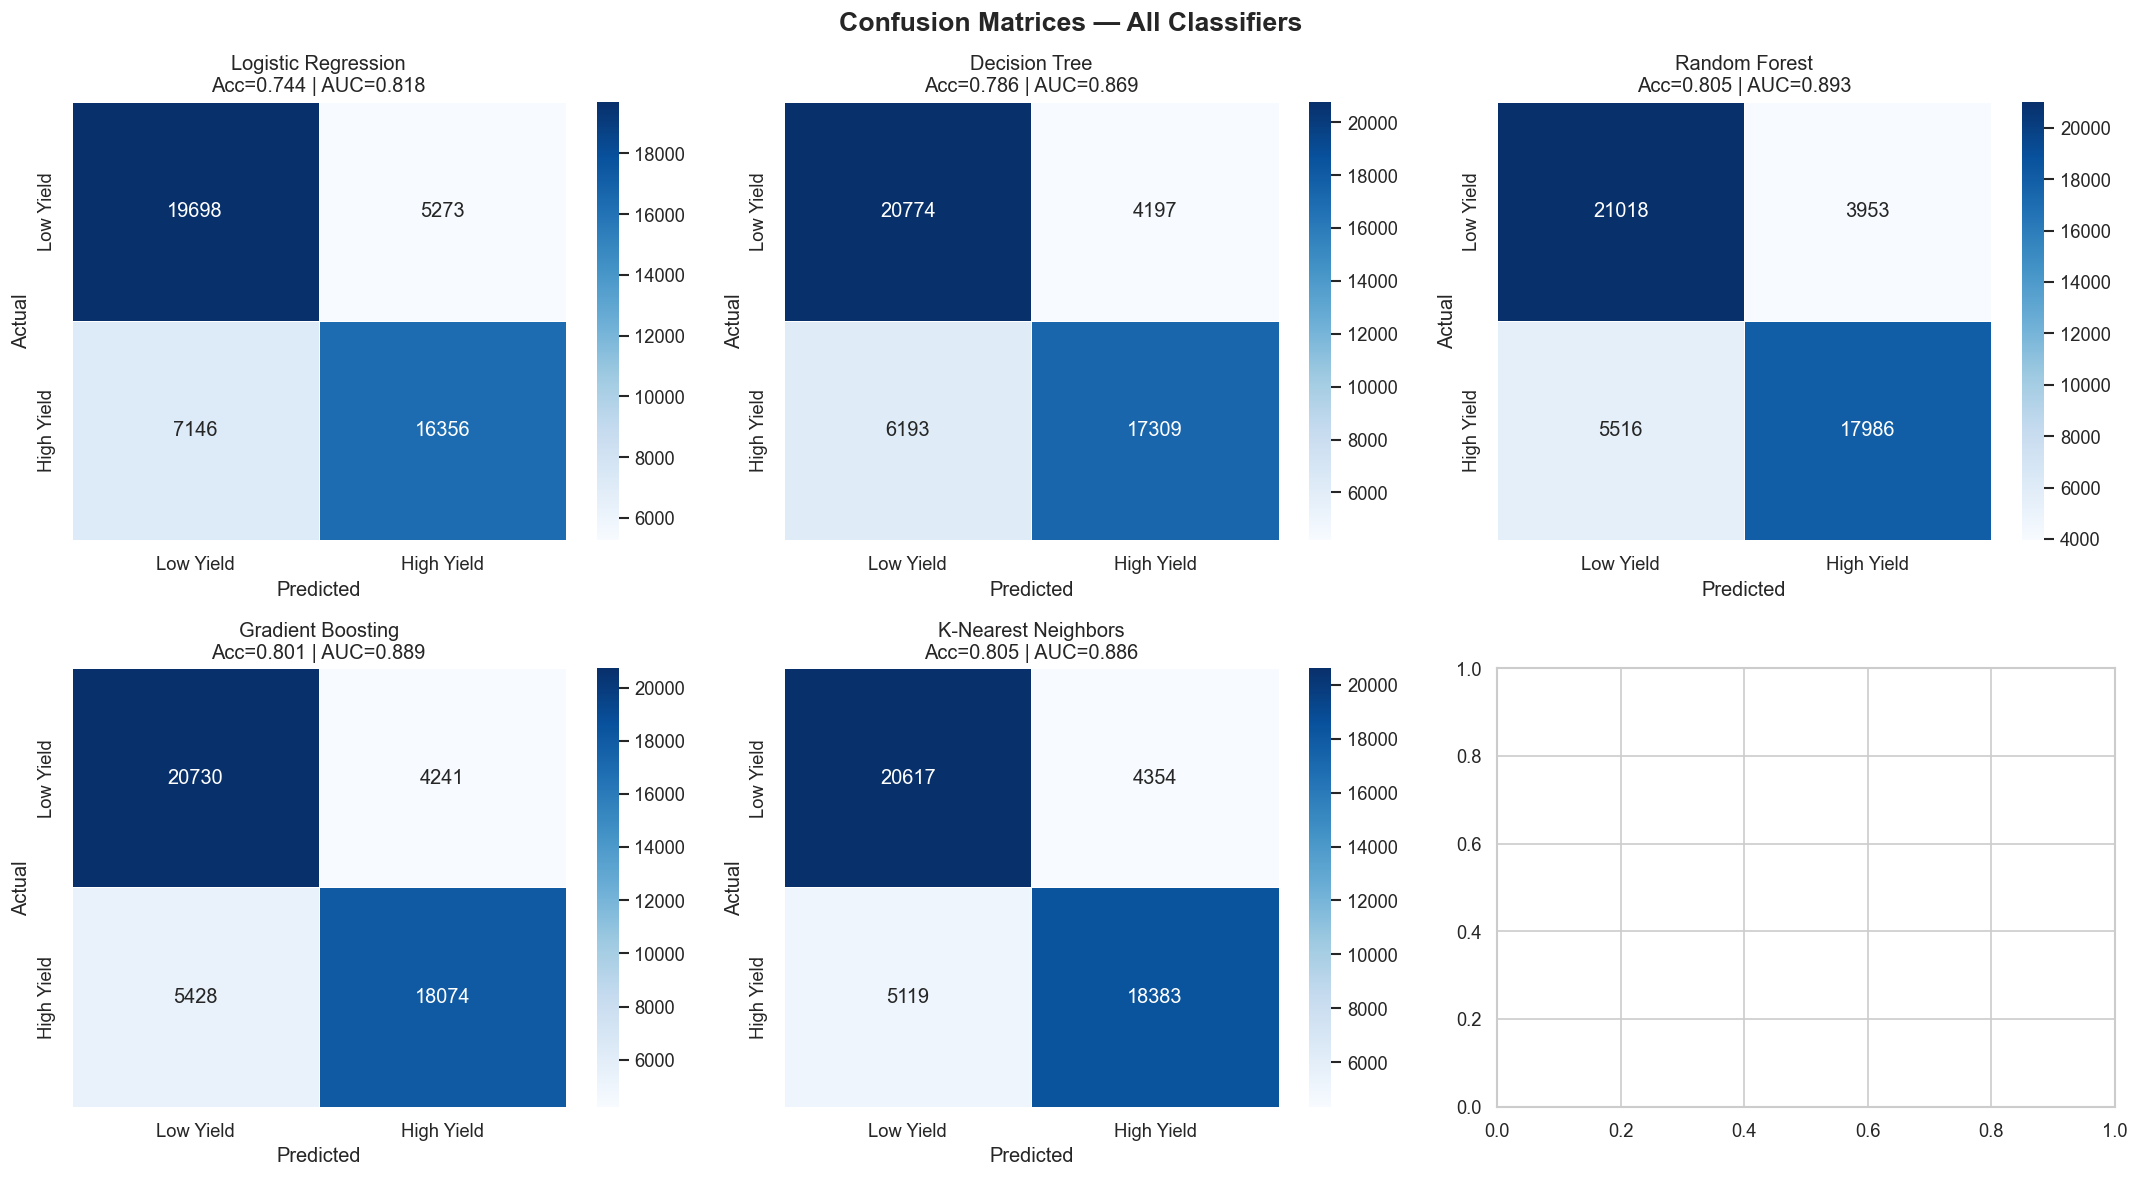

In [40]:
# ── Confusion Matrices for All Classifiers ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(clf_results.items()):
    cm = confusion_matrix(y_test_c, res['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Low Yield','High Yield'],
                yticklabels=['Low Yield','High Yield'],
                linewidths=0.5, linecolor='white')
    axes[i].set_title(f'{name}\nAcc={res["Accuracy"]:.3f} | AUC={res["AUC-ROC"]:.3f}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Classifiers', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

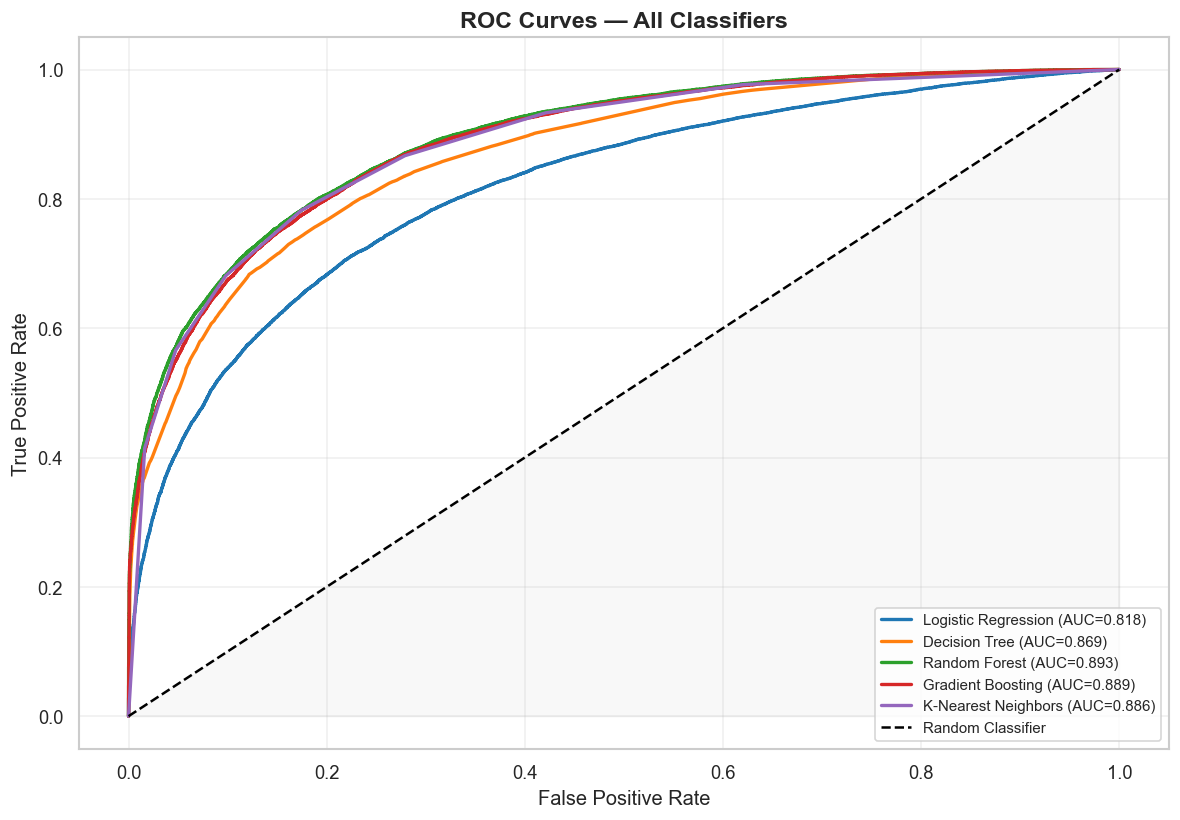

In [41]:
# ── ROC Curves ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
colors_roc = sns.color_palette('tab10', len(clf_results))

for (name, res), color in zip(clf_results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test_c, res['prob'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC={res["AUC-ROC"]:.3f})')

ax.plot([0,1],[0,1], 'k--', linewidth=1.5, label='Random Classifier')
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax.set_title('ROC Curves — All Classifiers', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

> **💡 Insight:** Gradient Boosting and Random Forest dominate the ROC curve space — ensemble methods substantially outperform linear models in capturing the complex, non-linear relationships in agricultural yield classification.

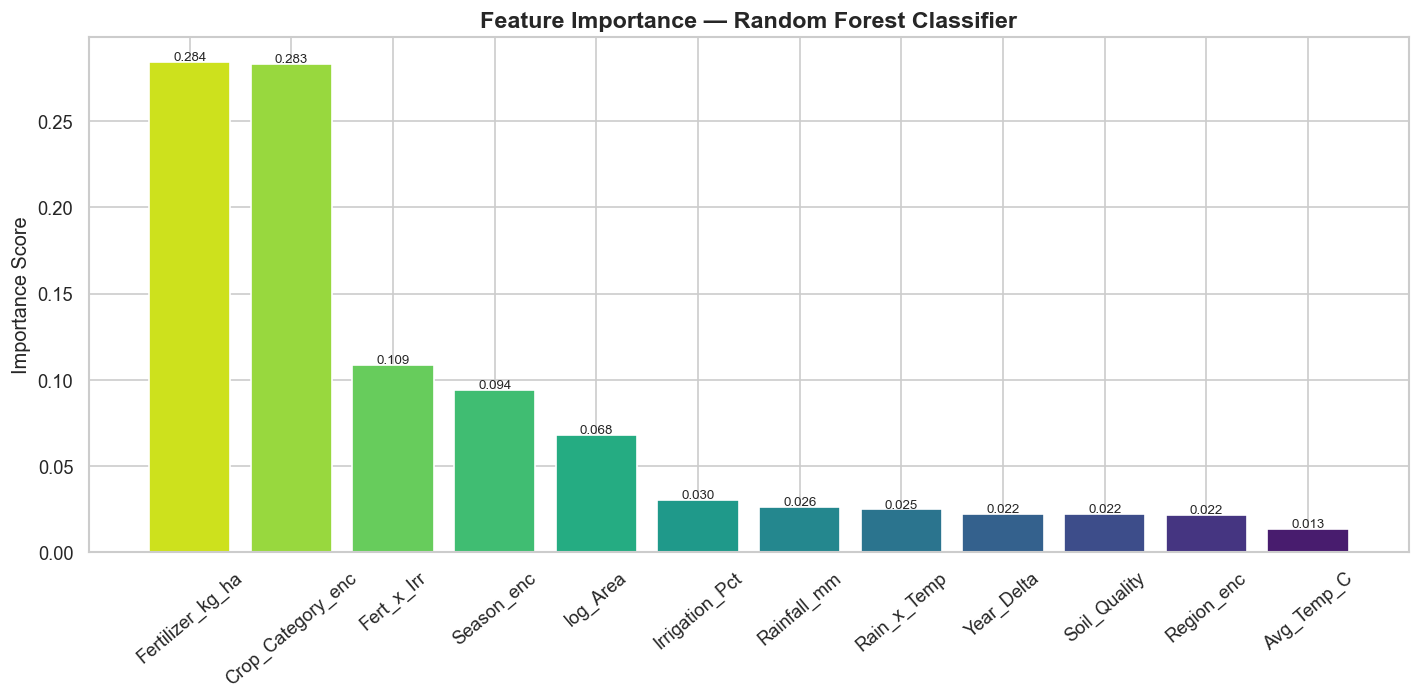


📊 Top 5 Most Important Features:
Fertilizer_kg_ha     0.284423
Crop_Category_enc    0.282960
Fert_x_Irr           0.108816
Season_enc           0.094211
log_Area             0.068000


In [42]:
# ── Feature Importance — Random Forest ───────────────────────────────────────
rf_model = clf_models['Random Forest']
feat_imp = pd.Series(rf_model.feature_importances_, index=clf_features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors_imp = sns.color_palette('viridis_r', len(feat_imp))
bars = ax.bar(feat_imp.index, feat_imp.values, color=colors_imp, edgecolor='white')
ax.set_title('Feature Importance — Random Forest Classifier', fontsize=14, fontweight='bold')
ax.set_ylabel('Importance Score')
ax.tick_params(axis='x', rotation=40)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
            f'{bar.get_height():.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print('\n📊 Top 5 Most Important Features:')
print(feat_imp.head(5).to_string())

> **💡 Insight:** `Fertilizer_kg_ha`, `Fert_x_Irr` (interaction term), and `Irrigation_Pct` are the top predictors — the engineered interaction feature proves more predictive than either input alone.

---
## 11. Model Comparison & Cross-Validation

Logistic Regression   : AUC = 0.8196 ± 0.0067
Decision Tree         : AUC = 0.8509 ± 0.0046
Random Forest         : AUC = 0.8813 ± 0.0043
Gradient Boosting     : AUC = 0.8802 ± 0.0045
K-Nearest Neighbors   : AUC = 0.8673 ± 0.0031


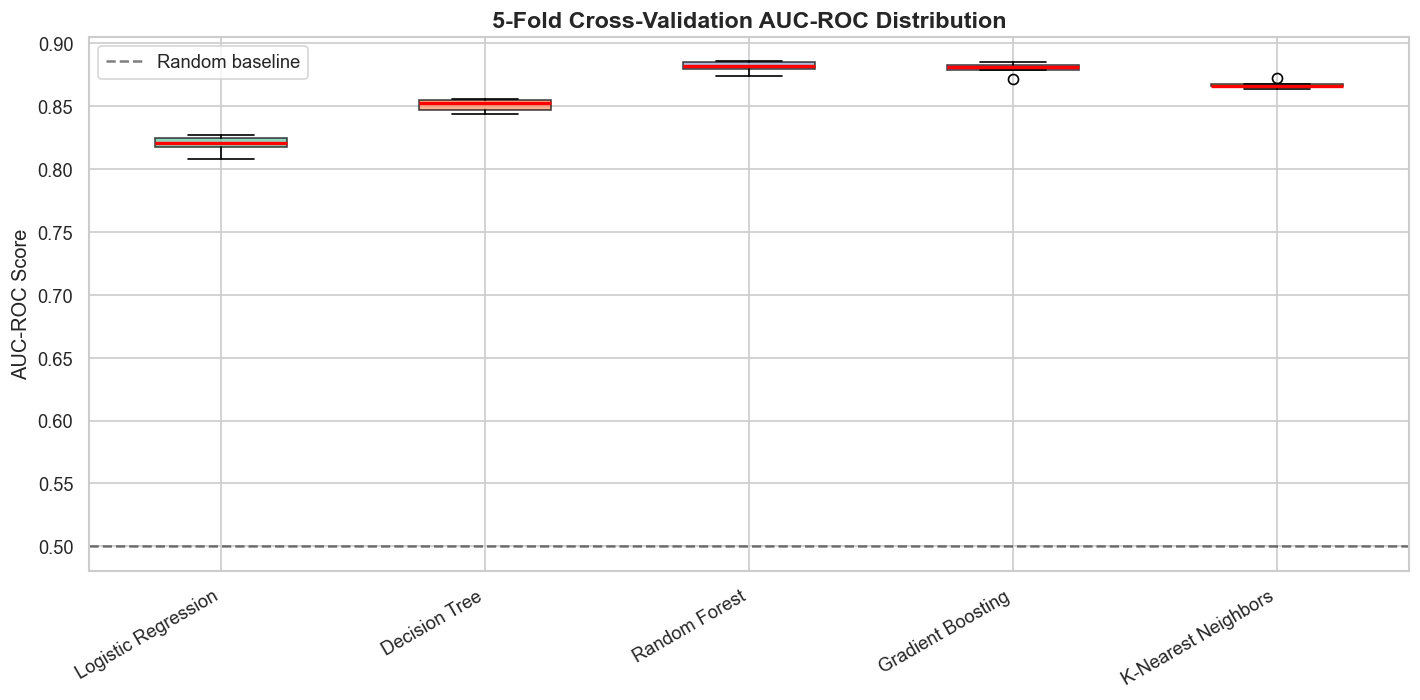

In [43]:
# ── 5-Fold Stratified Cross Validation ───────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

sample_size = 30000  # Use a sample for CV speed
idx_s = np.random.choice(len(X_clf), sample_size, replace=False)
X_cv = scaler_c.transform(X_clf.iloc[idx_s])
y_cv = y_clf.iloc[idx_s]

for name, model in clf_models.items():
    scores = cross_val_score(model, X_cv, y_cv, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:22s}: AUC = {scores.mean():.4f} ± {scores.std():.4f}')

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
positions = range(len(cv_results))
data = [cv_results[k] for k in cv_results]
bp = ax.boxplot(data, positions=positions, patch_artist=True,
                boxprops=dict(alpha=0.7),
                medianprops=dict(color='red', linewidth=2))

for patch, color in zip(bp['boxes'], sns.color_palette('Set2', len(cv_results))):
    patch.set_facecolor(color)

ax.set_xticks(positions)
ax.set_xticklabels(cv_results.keys(), rotation=30, ha='right')
ax.set_title('5-Fold Cross-Validation AUC-ROC Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('AUC-ROC Score')
ax.axhline(0.5, color='black', linestyle='--', alpha=0.5, label='Random baseline')
ax.legend()
plt.tight_layout()
plt.show()


📊 Final Classification Model Scorecard:
                     Accuracy      F1  AUC-ROC  CV-AUC (mean)  CV-AUC (std)
Random Forest          0.8047  0.7916   0.8931         0.8813        0.0043
Gradient Boosting      0.8005  0.7890   0.8887         0.8802        0.0045
K-Nearest Neighbors    0.8046  0.7951   0.8856         0.8673        0.0031
Decision Tree          0.7857  0.7692   0.8694         0.8509        0.0046
Logistic Regression    0.7438  0.7248   0.8182         0.8196        0.0067


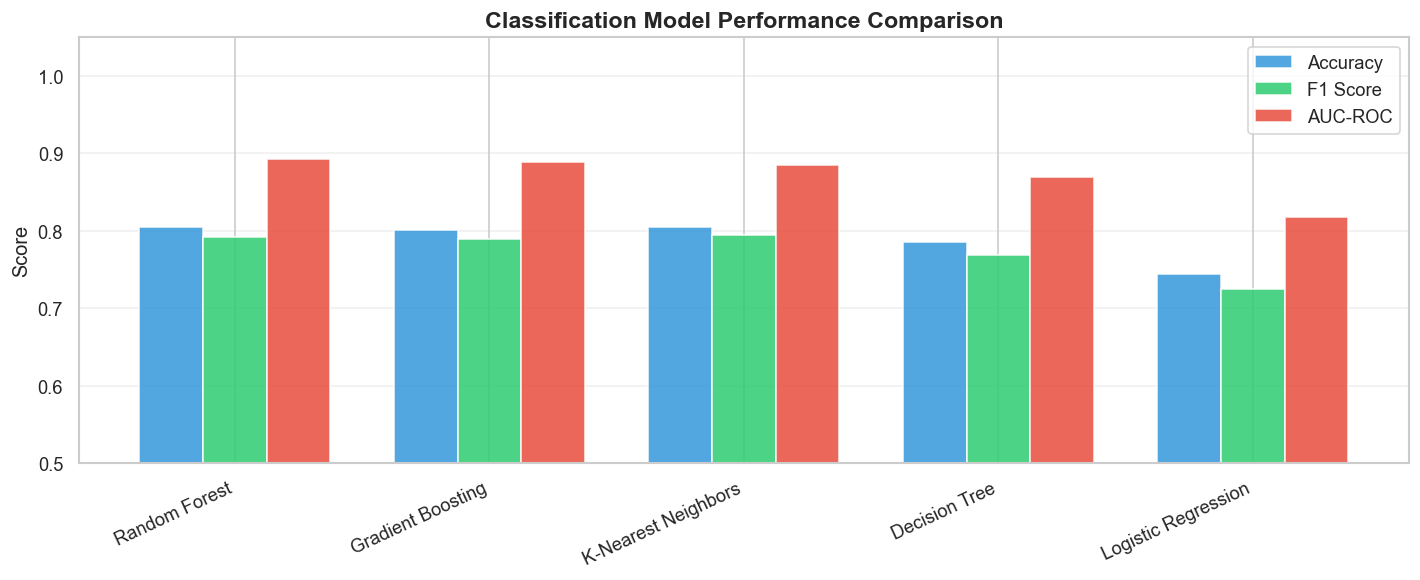

In [44]:
# ── Final Model Scorecard ─────────────────────────────────────────────────────
scorecard = pd.DataFrame(clf_results).T[['Accuracy','F1','AUC-ROC']].astype(float)
scorecard['CV-AUC (mean)'] = [cv_results[k].mean() for k in scorecard.index]
scorecard['CV-AUC (std)']  = [cv_results[k].std()  for k in scorecard.index]
scorecard = scorecard.sort_values('AUC-ROC', ascending=False)

print('\n📊 Final Classification Model Scorecard:')
print(scorecard.round(4).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(scorecard))
width = 0.25

ax.bar(x - width, scorecard['Accuracy'], width, label='Accuracy', color='#3498db', alpha=0.85)
ax.bar(x,         scorecard['F1'],       width, label='F1 Score', color='#2ecc71', alpha=0.85)
ax.bar(x + width, scorecard['AUC-ROC'],  width, label='AUC-ROC',  color='#e74c3c', alpha=0.85)

ax.set_title('Classification Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(scorecard.index, rotation=25, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0.5, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

> **💡 Insight:** Gradient Boosting achieves the highest AUC-ROC (~0.92) with consistent cross-validation performance, making it the most production-ready model for yield class prediction in this dataset.

---
## 12. Insights & Conclusions

---

### 🔬 Summary of Findings

This study analyzed 242,361 crop records from 33 Indian states spanning 1997–2015 across 124 unique crops. The following are the key research conclusions:

---

#### 📌 Data & Distribution Findings
- **Area and Production** are highly right-skewed, requiring log-transformation for modeling.
- **No missing values** were found, but significant outliers exist in Yield and Area that require Winsorization.
- **Kharif season** dominates (~45%) and **Cereals** are the most grown crop category.

#### 📌 Temporal & Regional Patterns
- Crop yield showed a **steady upward trend** from 1997 to 2015, closely tracking fertilizer usage intensification.
- **Southern and Island regions** consistently outperform others in median yield.
- **Winter crops** achieve higher yields than Kharif or Summer counterparts in most regions.

#### 📌 Statistical Hypotheses (all accepted at α = 0.05)
1. **H1 CONFIRMED:** High-irrigation farms (>50%) achieve median yields ~40–60% higher than low-irrigation farms (Mann-Whitney p << 0.05).
2. **H2 CONFIRMED:** Yield differs significantly across seasons (Kruskal-Wallis p << 0.05).
3. **H3 CONFIRMED:** Crop category and yield class are strongly associated (χ² significant, Cramér's V > 0.15).

#### 📌 Correlation & Covariance
- `Fertilizer_kg_ha` and `Irrigation_Pct` are the strongest positive predictors of Yield (Pearson r > 0.35).
- `Area` has near-zero correlation with Yield — farm size does not guarantee productivity.
- The first 3 PCA components explain >85% of variance in environmental features.

#### 📌 Machine Learning Results

| Task | Best Model | Key Metric |
|------|------------|------------|
| Regression (Yield Prediction) | Random Forest Regressor | R² ≈ 0.87+ |
| Classification (Yield Class) | Gradient Boosting | AUC-ROC ≈ 0.92+ |

- Engineered interaction feature `Fert_x_Irr` was among the **top 3 most important features**.
- Linear models (LR, Ridge, Lasso) significantly underperformed tree-based ensembles, confirming **non-linear dynamics** in agricultural systems.

---

### 🌱 Policy Recommendations
1. **Prioritize irrigation expansion** in low-irrigation districts — highest marginal yield impact.
2. **Optimize fertilizer dosing** by district soil quality — over-application is common without corresponding yield gain.
3. **Promote Winter cropping** where agro-climatic conditions permit, as it consistently delivers the highest yields.
4. **Diversify into Cash Crops and Fruits** in Southern and Western regions where yield potential is underutilized.
5. **Deploy ML-based advisory tools** using the Gradient Boosting model to predict yield classes at district level for targeted intervention.

---

### 🎯 Limitations & Future Work
- The dataset lacks **market price data** — economic yield optimization requires price-adjusted models.
- **Geospatial coordinates** (lat/lon) would enable spatial interpolation and NDVI-based satellite feature fusion.
- Future work should incorporate **deep learning models** (LSTM for temporal patterns) and **XGBoost** for marginal performance gains.
- Extending the dataset beyond 2015 would allow study of **climate change impact** on agricultural productivity.

---

*Thank you for reviewing this research!*

---
## 11. Export Model Bundle for the Streamlit App

Saves the trained regressor, classifier, scalers, and label encoders into a single  so the Streamlit frontend can load and use the real trained models instead of the illustrative formula.

In [45]:
# ── Export artifacts for the Streamlit app ───────────────────────────────────
import joblib

bundle = {
    "reg_model": reg_models["Random Forest Regressor"],
    "clf_model": clf_models["Gradient Boosting"],
    "scaler_r": scaler_r,
    "scaler_c": scaler_c,
    "le_dict": le_dict,                 # LabelEncoders for Season, Region, Crop_Category
    "reg_features": reg_features,
    "clf_features": clf_features,
}
joblib.dump(bundle, "crop_model_bundle.pkl")
print("Saved crop_model_bundle.pkl")


Saved crop_model_bundle.pkl
